In [1]:
"""VAE U-DiT: interactive notebook experiment.

Explores diffusion-transformer image generation using the raw architecture and
DiffusionModel wrapper selected in its cells. Related numbered copies retain their own
architecture, conditioning, reshaping, and training choices; this file uses the literal
values written below.

Inputs are loaded image/label arrays and the model, schedule, optimizer, callback, and
fit settings in the setup cells. get_dataset documents byte scaling, optional channel
insertion, label handling, shuffle behavior, and batch defaults. Wrapper
constructor/method docstrings define the remaining selected modes.

Outputs include a trained model, fit histories, sampled images, and any configured
callback/checkpoint files. Executing cells may download data, allocate TensorFlow
resources, train weights, and write artifacts. Cell definitions do not run a complete
experiment automatically, and notebook-wide names depend on prior setup execution.
"""

import init

In [2]:
epochs = 50 # or 50 to get acc of 0.9850

In [3]:
import tensorflow as tf


def get_dataset(x, y, batch_size=128, shuffle_buffer=10_000, drop_remainder=True):
    """Scale image bytes to diffusion space and batch aligned labels.

    The affine transform does not clip values. No prefetching, repetition, validation
    split, or deterministic shuffle seed is added. Labels remain aligned with images
    while shuffling.

    Args:
        x (np.ndarray): Image values nominally in [0, 255]. Trailing image dimensions
            are preserved; supply the channel dimension required by the model.
        y (np.ndarray): Labels with the same leading length as x. Values and label shape
            are preserved.
        batch_size (int): Number of examples in each dataset batch. Defaults to ``128``.
        shuffle_buffer (int | None): None preserves input order; a positive integer
            enables shuffling without an explicit operation seed. TensorFlow global
            seeding can still control this randomness. Defaults to ``10000``.
        drop_remainder (bool): True discards an incomplete final batch; False retains
            it. Defaults to ``True``.

    Returns:
        tf.data.Dataset: Finite (images, labels) batches, with float32 image values
        transformed as 2*x/255-1 and the configured remainder policy.
    """

    x = x.astype("float32") / 255.0
    x = (x * 2.0) - 1.0
    # x = x[..., None]

    dataset = tf.data.Dataset.from_tensor_slices((x, y))

    # A supplied buffer enables random shuffling; None keeps input order.
    if shuffle_buffer is not None:
        dataset = dataset.shuffle(shuffle_buffer)

    dataset = dataset.batch(batch_size, drop_remainder=drop_remainder)

    return dataset

In [4]:
from tensorflow.keras import datasets, layers

import numpy as np


(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

x_train = np.expand_dims(x_train, -1)
x_train = layers.ZeroPadding2D((2, 2))(x_train).numpy()

x_test = np.expand_dims(x_test, -1)
x_test = layers.ZeroPadding2D((2, 2))(x_test).numpy()

trainset = get_dataset(x_train, y_train)
valset = get_dataset(x_test, y_test, shuffle_buffer=None, drop_remainder=False)

In [5]:
from diffusion.models.wrapper.diffusion_model import DiffusionModel
from diffusion.models.transformer.diffusion_transformer import DiffusionTransformer


vit = DiffusionTransformer(
    image_size=32, 
    use_cfg=False, 
    dim_forced=False, 
    depth=15, 
    connection_ids_dict={8: (3,), 10: (1,), 12: (7,)}, 
    cross_attention_ids_dict={13: (9,), 15: (11,)}, 
    cross_attention_kwargs={
        "use_layer_norm": True, 
        "ln_no_adaptation": False
    }, 
    vit_block_ids=[1, 3, 5, 13, 15], 
    use_decoder_ids=[13, 15], 
    vit_block_mlp_output_dims={1: 32, 3: 64, 5: 64, 13: 32, 15: 32}, 
    downsample_ids=[2, 4], 
    downsample_kwargs={
        "pos_embed_type": "2d_sincos", 
    }, 
    upsample_ids=[12, 14], 
    upsample_kwargs={
        "pos_embed_type": "2d_sincos", 
        "scaling_method": "interpolate", 
        "scaling_interpolation_method": "bilinear"
    }, 
    reshaper_ids_dict={
        6: "flatten", 7: "unflatten", 
        8: "flatten", 9: "unflatten", 
        10: "flatten", 11: "unflatten"
    }, 
    reshaper_kwargs={
        "add_kl": True, 
        "latent_dim_ratio": [1 / 32, 1 / 128, 1 / 256]
    }
)
model = DiffusionModel(
    network=vit, 
    swap_noise_image=True, 
    kl_loss_coef=0.01, 
    modify_first_t=True, 
    train_noisified_max_timesteps=0, 
    test_noisified_max_timesteps=0, 
) # 

vit.summary()

Model: "diffusion_transformer"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 depth_0_patch_embedder (Pat  (None, 256, 32)          160       
 chEmbedding)                                                    
                                                                 
 depth_0_time_embedder (Cond  (None, 32)               32000     
 itionEmbedding)                                                 
                                                                 
 depth_0_label_embedder (Con  (None, 32)               320       
 ditionEmbedding)                                                
                                                                 
 depth_0_time_label_merger (  (None, 32)               0         
 Add)                                                            
                                                                 
 depth_1_encoder_block (Visi  (None, 256, 32)

In [28]:
from tensorflow.keras import optimizers


lr_schedule = optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3, 
    decay_steps=epochs * len(trainset), #  * 11
)

model.compile(
    optimizer=optimizers.Adam(lr_schedule), 
    loss="mse", 
    # run_eagerly=True
)

In [7]:
from tensorflow.keras import callbacks

from diffusion import ImageGeneratorCallback
from common.lr_logger_callback import LrLoggerCallback


callbacks_list = [
    LrLoggerCallback(), 
    callbacks.ProgbarLogger(count_mode="steps"), 
    ImageGeneratorCallback(), 
]

In [8]:
# model.set_current_resolution(14)

In [9]:
# model.set_current_resolution(28)

In [10]:
# model.set_current_resolution(56)

In [11]:
model.set_current_resolution(16)

Epoch 1/50
468/468 [==============================] - 75s 139ms/step - loss: 0.1492 - noise_loss: 0.1197 - kl_loss: 2.9533 - val_loss: 0.1990 - val_noise_loss: 0.1402 - val_image_loss: 0.0000e+00 - val_kl_loss: 5.8844 - learning_rate: 9.9901e-04


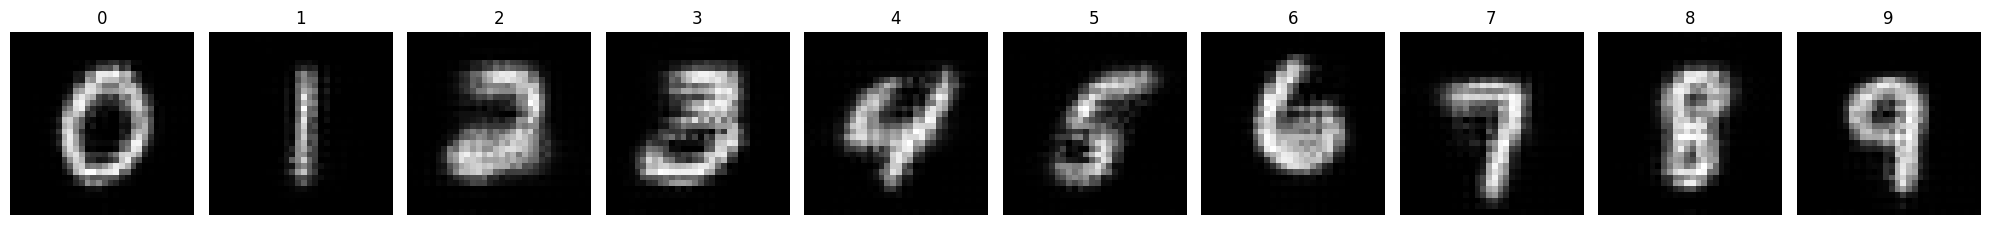

Epoch 2/50
468/468 [==============================] - 67s 143ms/step - loss: 0.1361 - noise_loss: 0.1116 - kl_loss: 2.4458 - val_loss: 0.1583 - val_noise_loss: 0.1229 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.5392 - learning_rate: 9.9606e-04


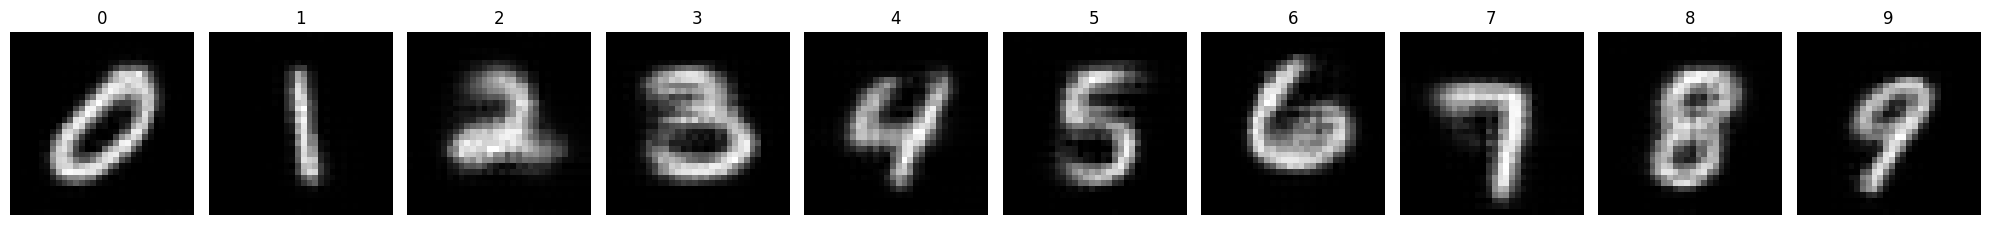

Epoch 3/50
468/468 [==============================] - 68s 145ms/step - loss: 0.1350 - noise_loss: 0.1097 - kl_loss: 2.5288 - val_loss: 0.1420 - val_noise_loss: 0.1138 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.8176 - learning_rate: 9.9114e-04


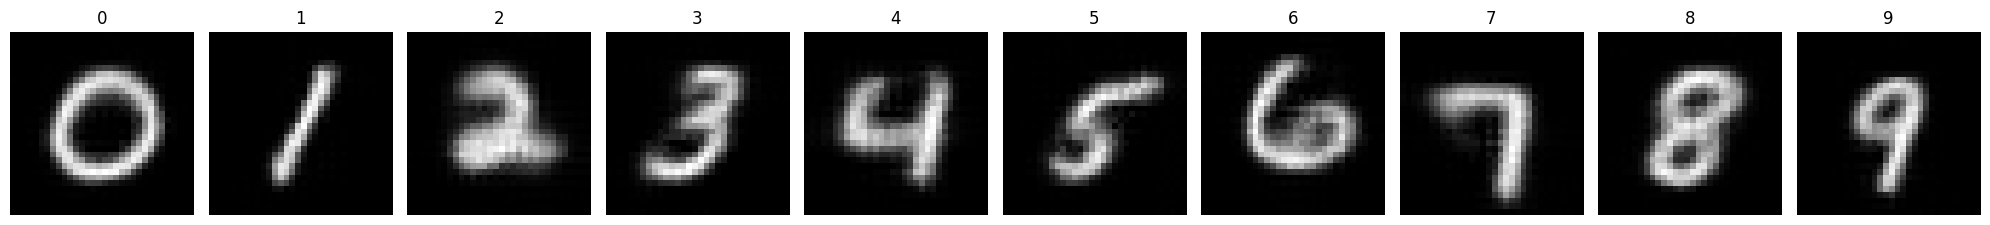

Epoch 4/50
468/468 [==============================] - 67s 143ms/step - loss: 0.1341 - noise_loss: 0.1081 - kl_loss: 2.5993 - val_loss: 0.1355 - val_noise_loss: 0.1094 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.6091 - learning_rate: 9.8429e-04


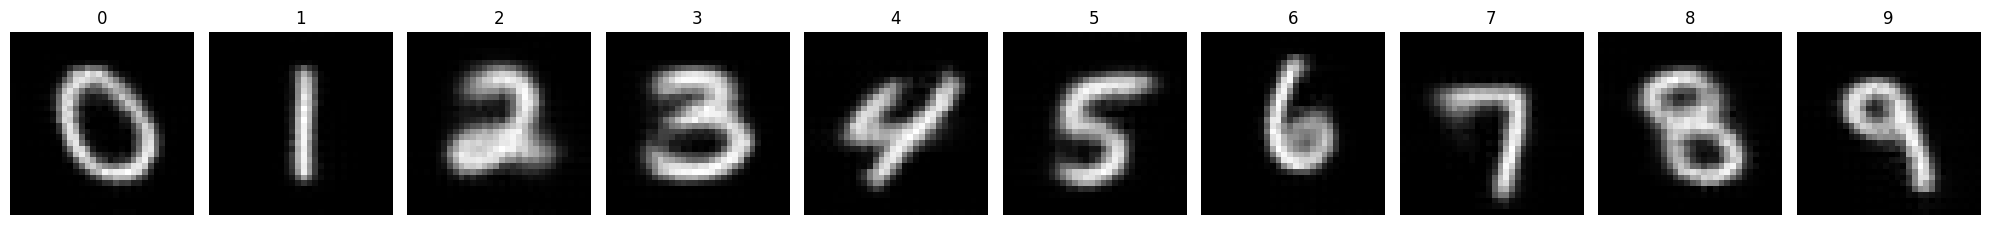

Epoch 5/50
468/468 [==============================] - 66s 141ms/step - loss: 0.1337 - noise_loss: 0.1071 - kl_loss: 2.6661 - val_loss: 0.1326 - val_noise_loss: 0.1069 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.5715 - learning_rate: 9.7553e-04


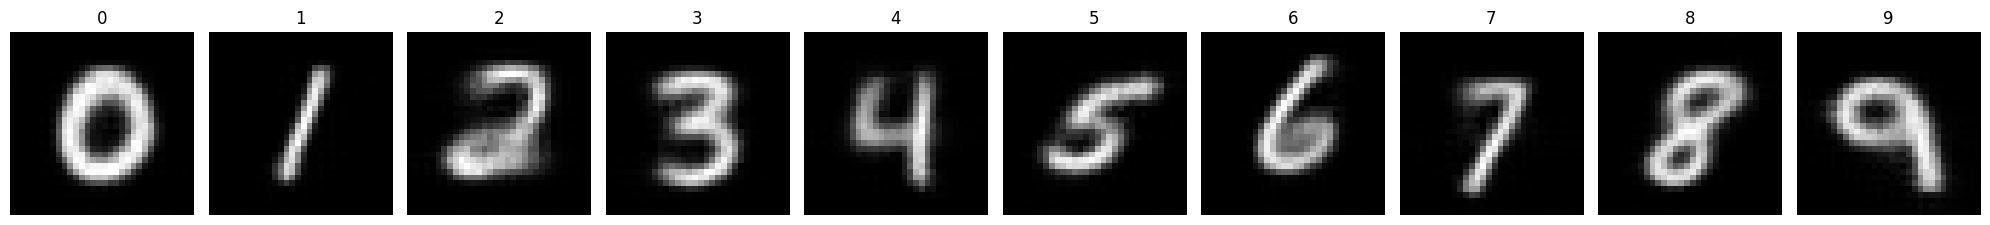

Epoch 6/50
468/468 [==============================] - 67s 142ms/step - loss: 0.1334 - noise_loss: 0.1061 - kl_loss: 2.7236 - val_loss: 0.1311 - val_noise_loss: 0.1051 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.5978 - learning_rate: 9.6489e-04


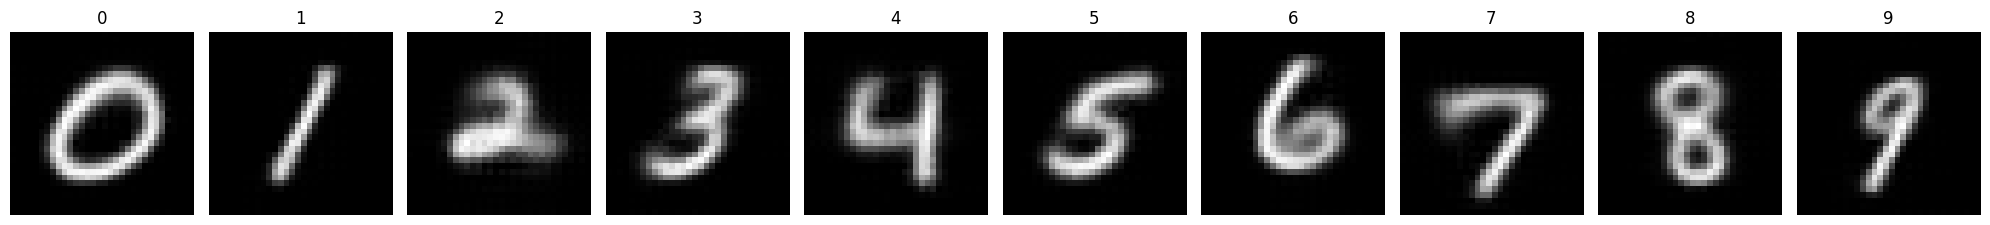

Epoch 7/50
468/468 [==============================] - 67s 143ms/step - loss: 0.1328 - noise_loss: 0.1052 - kl_loss: 2.7638 - val_loss: 0.1303 - val_noise_loss: 0.1040 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.6355 - learning_rate: 9.5241e-04


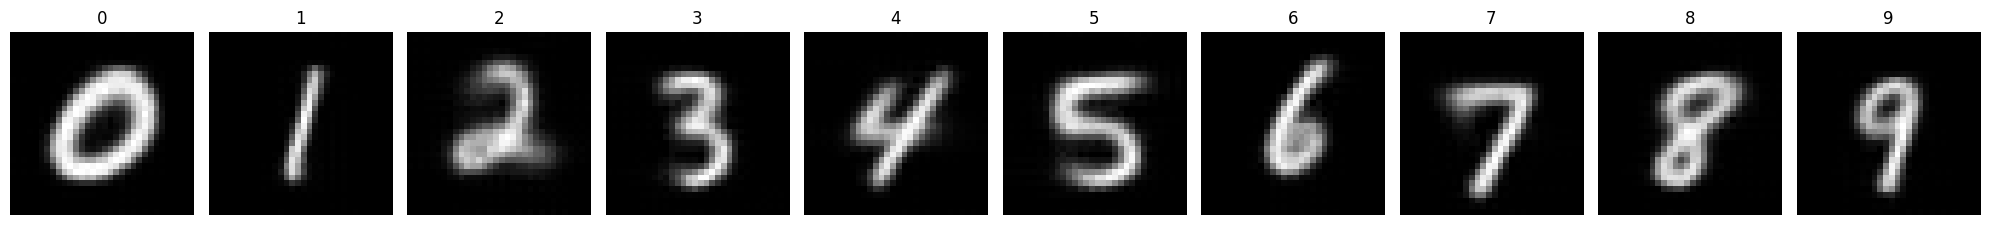

Epoch 8/50
468/468 [==============================] - 67s 143ms/step - loss: 0.1324 - noise_loss: 0.1041 - kl_loss: 2.8336 - val_loss: 0.1298 - val_noise_loss: 0.1029 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.6903 - learning_rate: 9.3815e-04


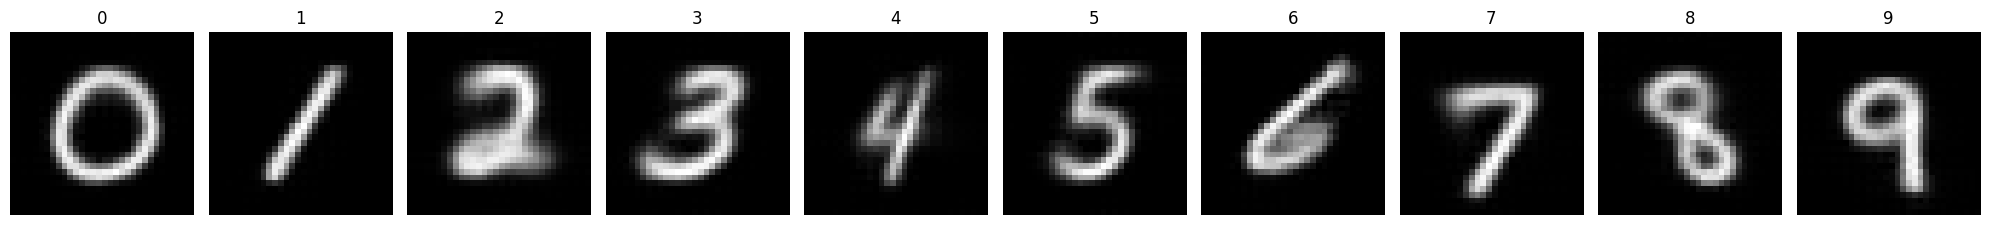

Epoch 9/50
468/468 [==============================] - 67s 142ms/step - loss: 0.1322 - noise_loss: 0.1032 - kl_loss: 2.8951 - val_loss: 0.1293 - val_noise_loss: 0.1019 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.7419 - learning_rate: 9.2216e-04


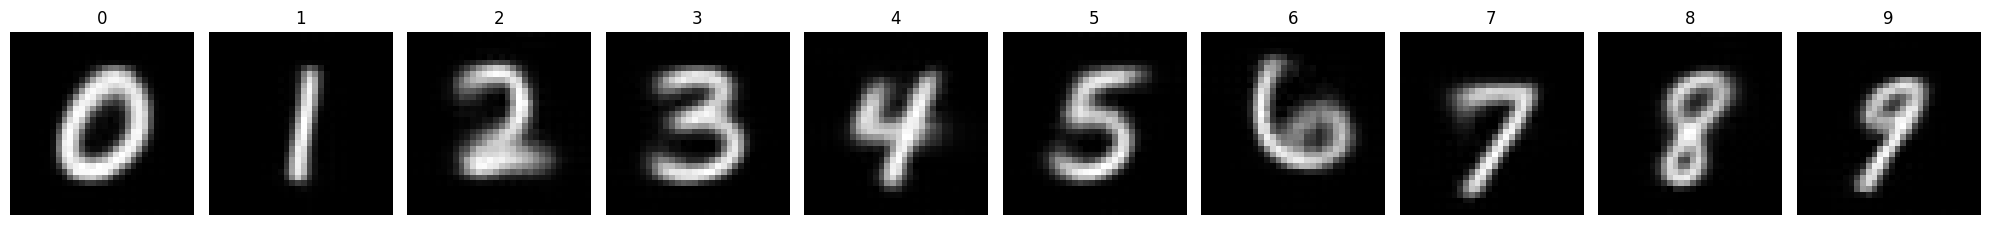

Epoch 10/50
468/468 [==============================] - 67s 143ms/step - loss: 0.1317 - noise_loss: 0.1023 - kl_loss: 2.9374 - val_loss: 0.1287 - val_noise_loss: 0.1008 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.7907 - learning_rate: 9.0451e-04


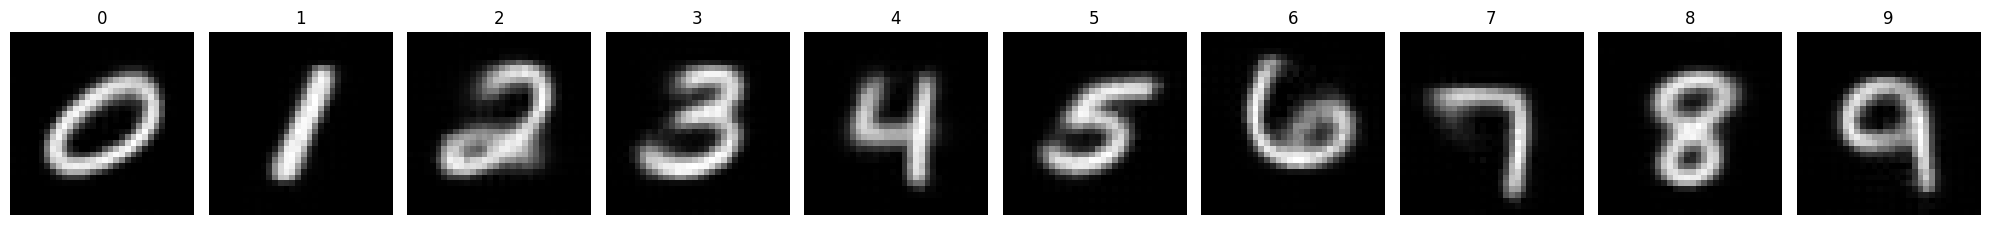

Epoch 11/50
468/468 [==============================] - 70s 149ms/step - loss: 0.1313 - noise_loss: 0.1015 - kl_loss: 2.9848 - val_loss: 0.1286 - val_noise_loss: 0.1002 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.8412 - learning_rate: 8.8526e-04


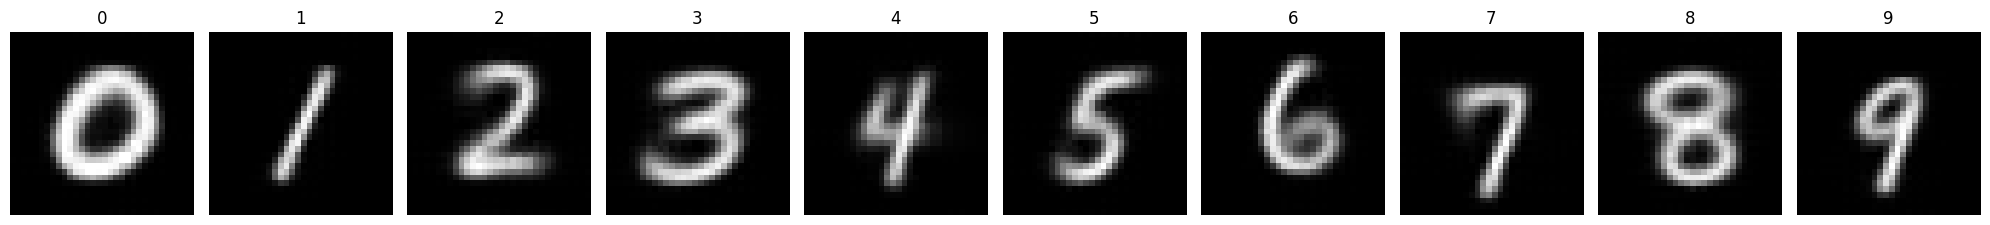

Epoch 12/50
468/468 [==============================] - 63s 134ms/step - loss: 0.1310 - noise_loss: 0.1008 - kl_loss: 3.0207 - val_loss: 0.1283 - val_noise_loss: 0.0994 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.8854 - learning_rate: 8.6448e-04


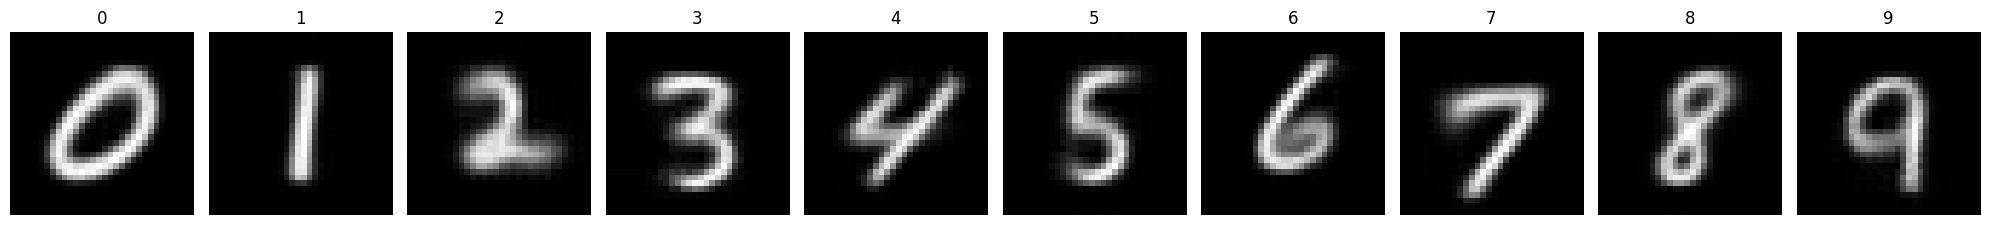

Epoch 13/50
468/468 [==============================] - 63s 135ms/step - loss: 0.1304 - noise_loss: 0.0998 - kl_loss: 3.0634 - val_loss: 0.1280 - val_noise_loss: 0.0987 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.9313 - learning_rate: 8.4227e-04


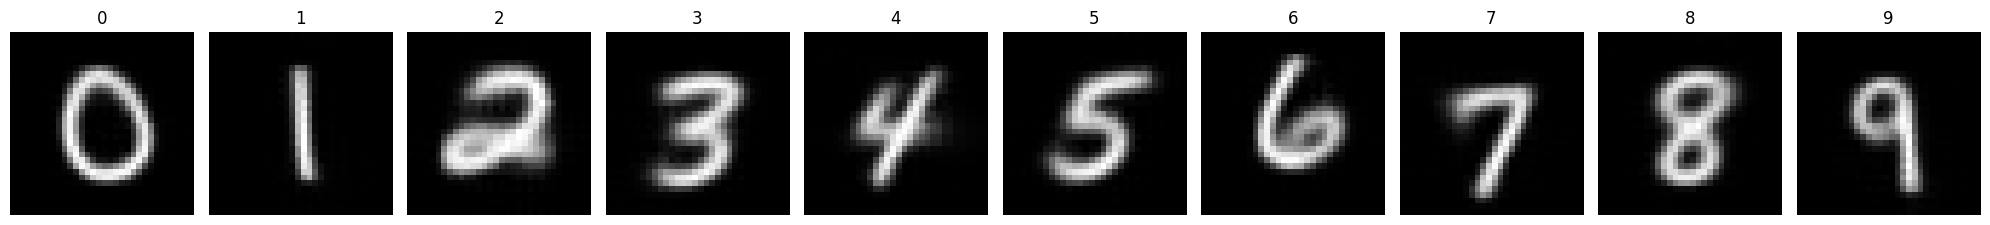

Epoch 14/50
468/468 [==============================] - 63s 135ms/step - loss: 0.1302 - noise_loss: 0.0990 - kl_loss: 3.1173 - val_loss: 0.1277 - val_noise_loss: 0.0979 - val_image_loss: 0.0000e+00 - val_kl_loss: 2.9790 - learning_rate: 8.1871e-04


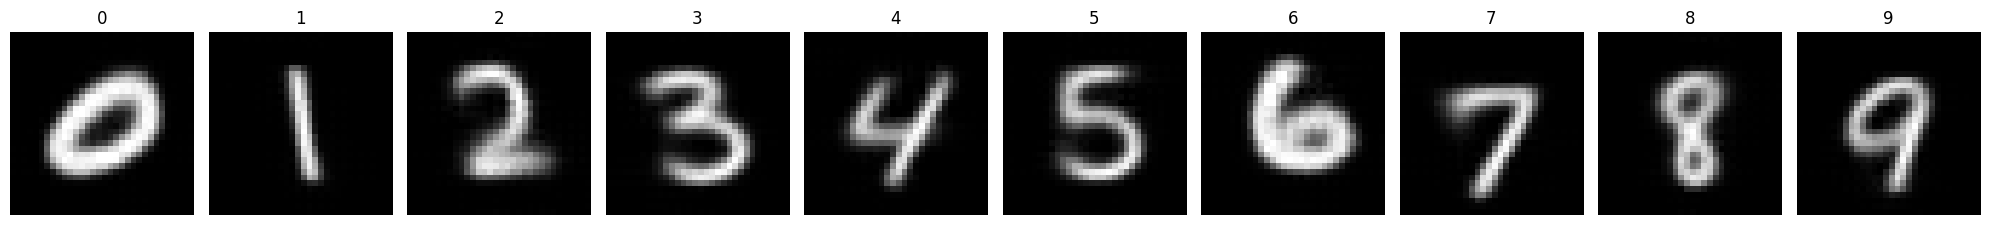

Epoch 15/50
468/468 [==============================] - 63s 135ms/step - loss: 0.1299 - noise_loss: 0.0983 - kl_loss: 3.1622 - val_loss: 0.1275 - val_noise_loss: 0.0972 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.0273 - learning_rate: 7.9389e-04


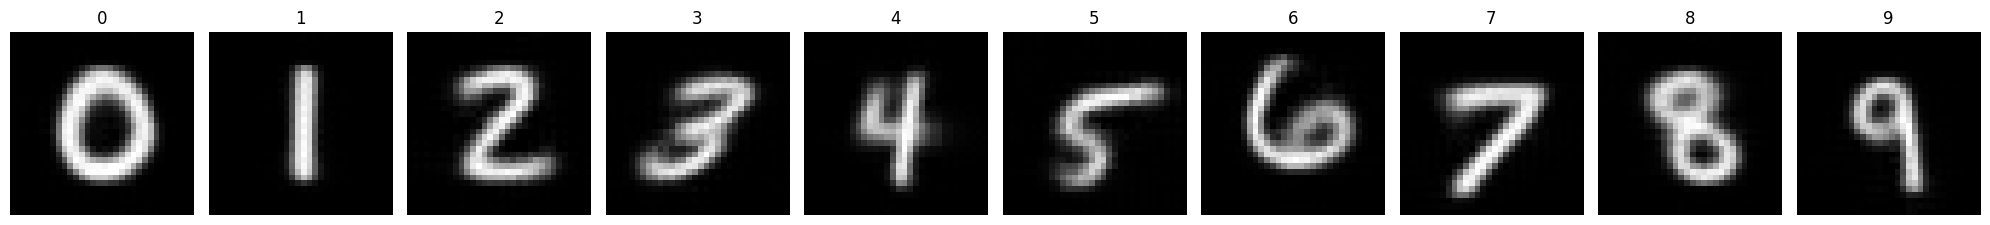

Epoch 16/50
468/468 [==============================] - 63s 134ms/step - loss: 0.1295 - noise_loss: 0.0975 - kl_loss: 3.2027 - val_loss: 0.1271 - val_noise_loss: 0.0964 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.0710 - learning_rate: 7.6791e-04


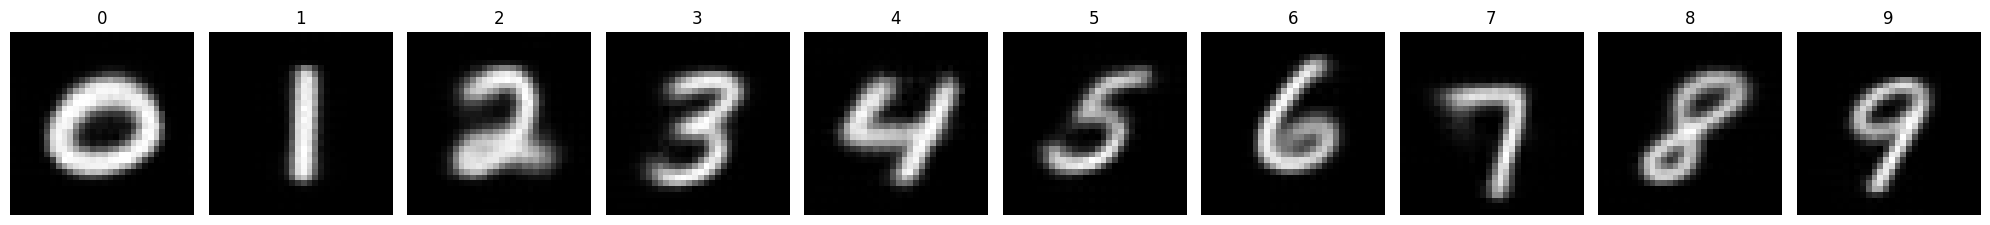

Epoch 17/50
468/468 [==============================] - 63s 134ms/step - loss: 0.1293 - noise_loss: 0.0968 - kl_loss: 3.2492 - val_loss: 0.1268 - val_noise_loss: 0.0956 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.1181 - learning_rate: 7.4088e-04


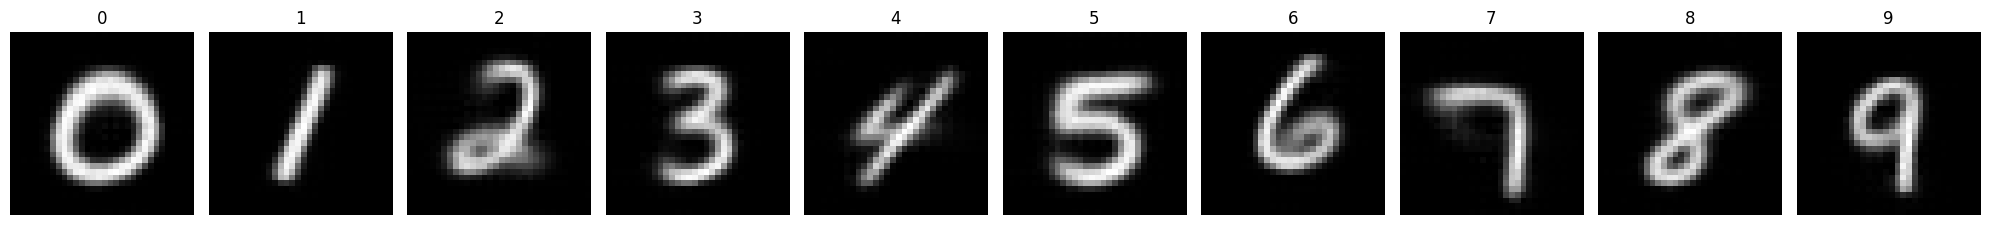

Epoch 18/50
468/468 [==============================] - 63s 134ms/step - loss: 0.1288 - noise_loss: 0.0959 - kl_loss: 3.2844 - val_loss: 0.1266 - val_noise_loss: 0.0949 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.1642 - learning_rate: 7.1289e-04


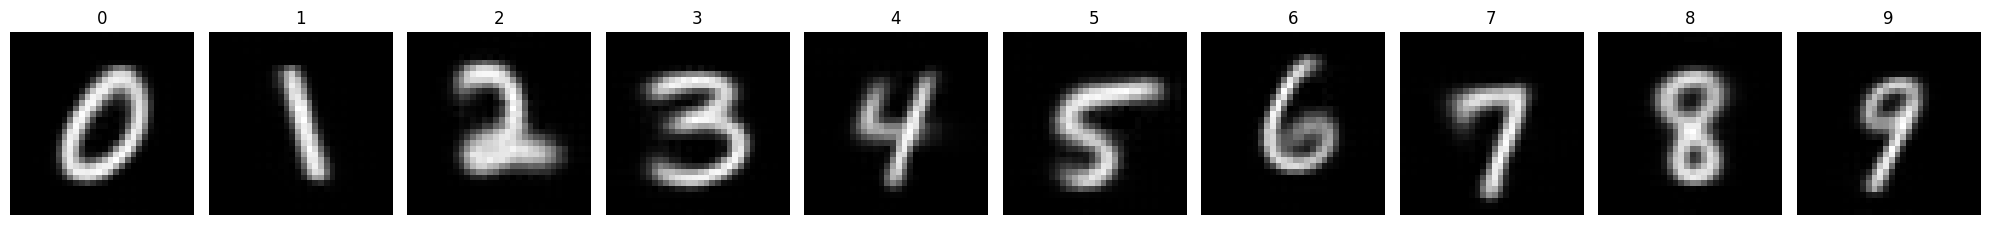

Epoch 19/50
468/468 [==============================] - 63s 134ms/step - loss: 0.1286 - noise_loss: 0.0953 - kl_loss: 3.3286 - val_loss: 0.1262 - val_noise_loss: 0.0941 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.2126 - learning_rate: 6.8406e-04


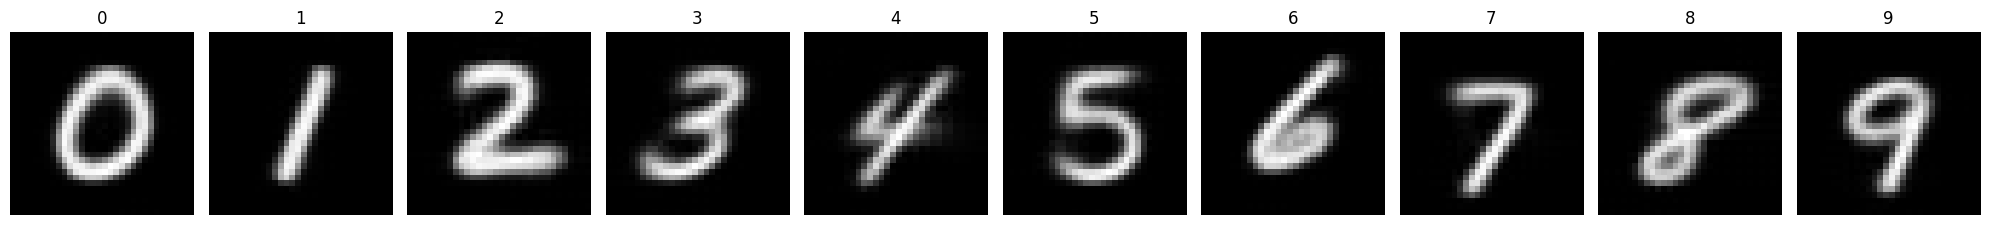

Epoch 20/50
468/468 [==============================] - 63s 135ms/step - loss: 0.1281 - noise_loss: 0.0946 - kl_loss: 3.3546 - val_loss: 0.1260 - val_noise_loss: 0.0935 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.2552 - learning_rate: 6.5451e-04


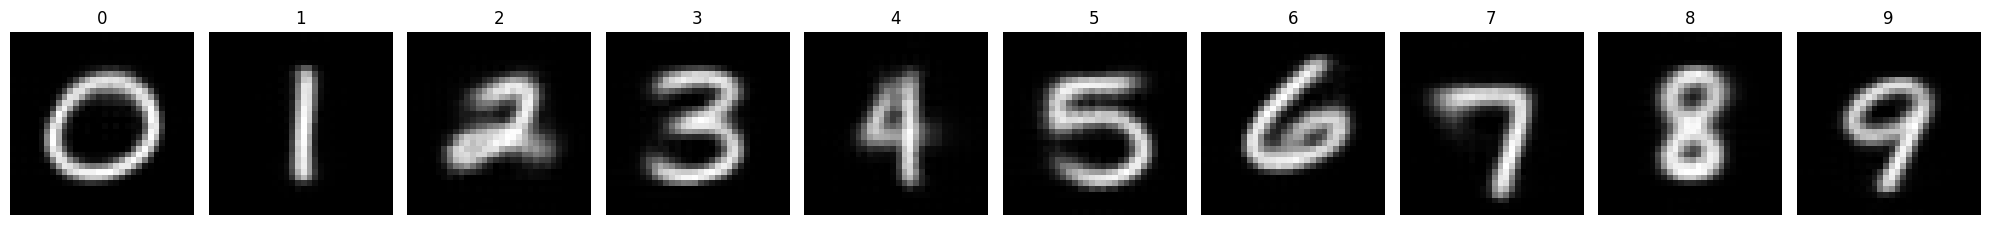

Epoch 21/50
468/468 [==============================] - 63s 135ms/step - loss: 0.1280 - noise_loss: 0.0941 - kl_loss: 3.3950 - val_loss: 0.1256 - val_noise_loss: 0.0926 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.2997 - learning_rate: 6.2435e-04


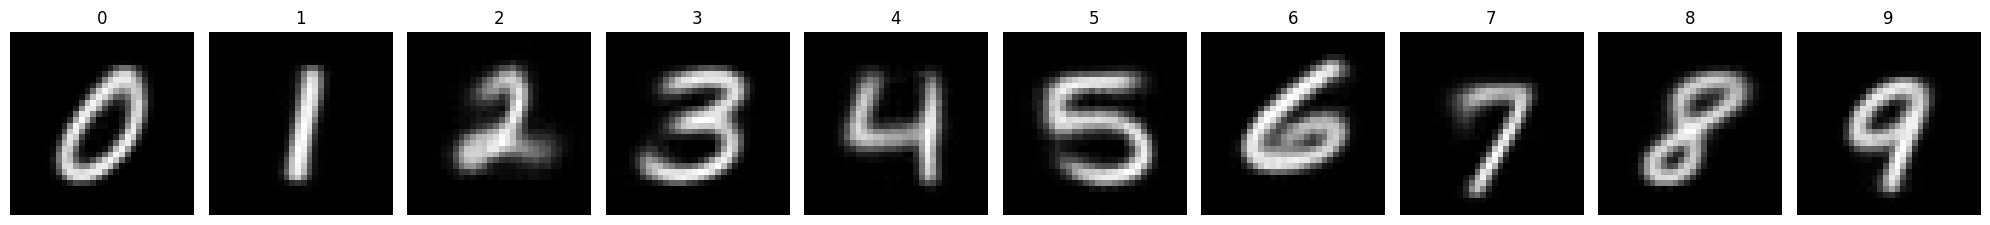

Epoch 22/50
468/468 [==============================] - 63s 134ms/step - loss: 0.1278 - noise_loss: 0.0935 - kl_loss: 3.4331 - val_loss: 0.1254 - val_noise_loss: 0.0920 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.3411 - learning_rate: 5.9369e-04


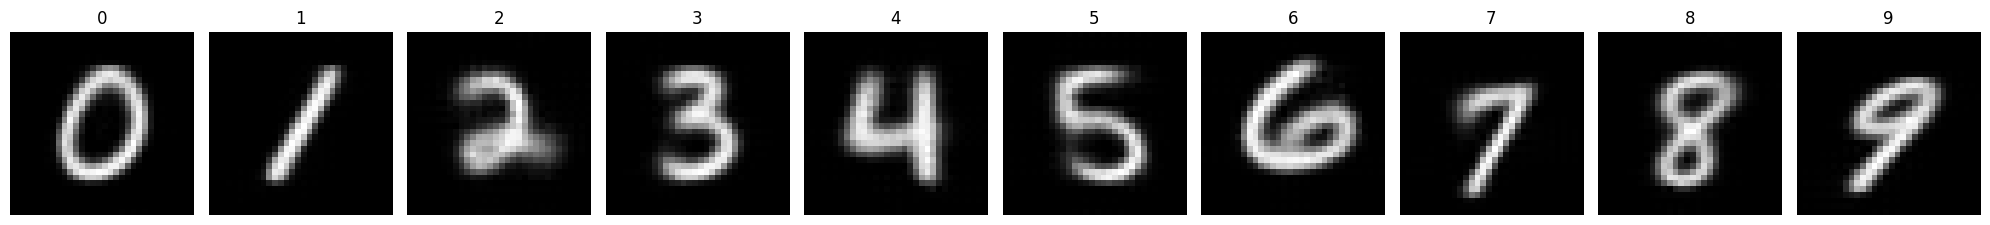

Epoch 23/50
468/468 [==============================] - 63s 135ms/step - loss: 0.1274 - noise_loss: 0.0929 - kl_loss: 3.4526 - val_loss: 0.1251 - val_noise_loss: 0.0913 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.3758 - learning_rate: 5.6267e-04


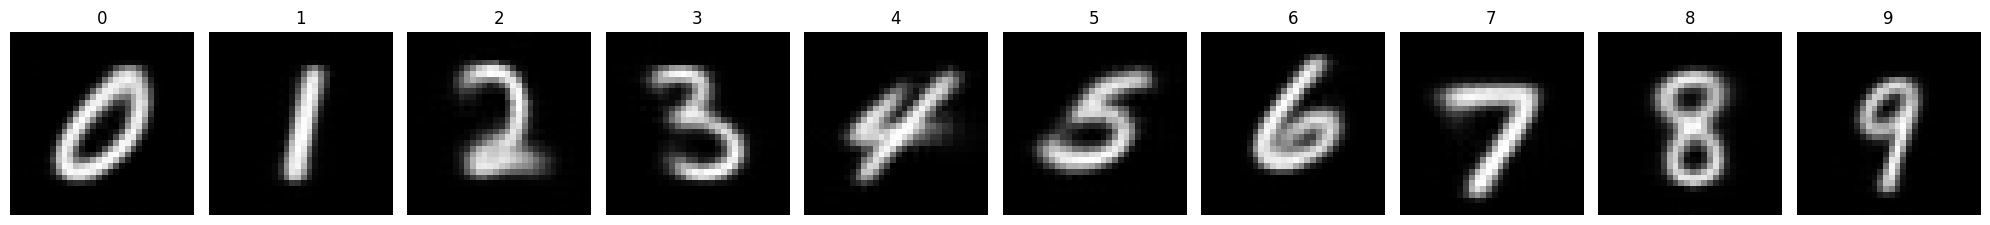

Epoch 24/50
468/468 [==============================] - 63s 134ms/step - loss: 0.1272 - noise_loss: 0.0924 - kl_loss: 3.4878 - val_loss: 0.1253 - val_noise_loss: 0.0912 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.4105 - learning_rate: 5.3140e-04


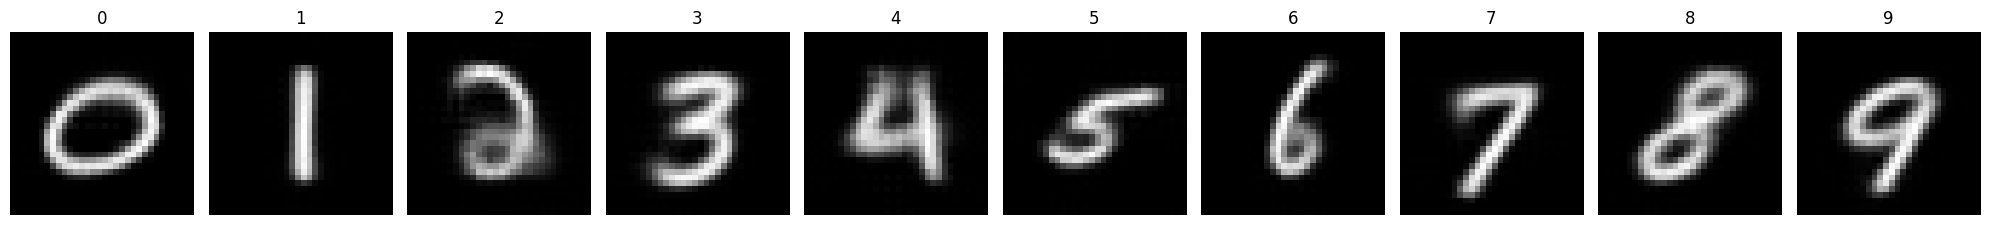

Epoch 25/50
468/468 [==============================] - 63s 134ms/step - loss: 0.1270 - noise_loss: 0.0920 - kl_loss: 3.5034 - val_loss: 0.1251 - val_noise_loss: 0.0907 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.4396 - learning_rate: 5.0000e-04


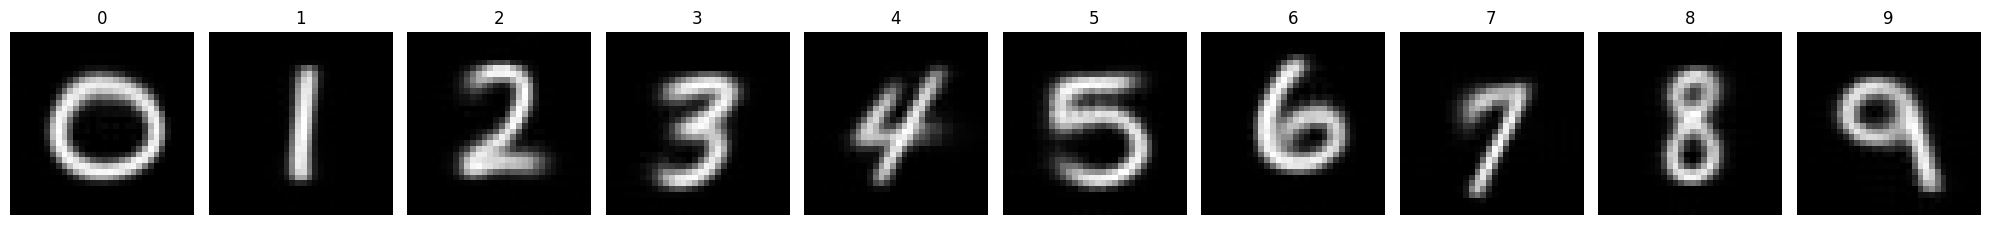

Epoch 26/50
468/468 [==============================] - 63s 134ms/step - loss: 0.1268 - noise_loss: 0.0915 - kl_loss: 3.5222 - val_loss: 0.1249 - val_noise_loss: 0.0903 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.4661 - learning_rate: 4.6860e-04


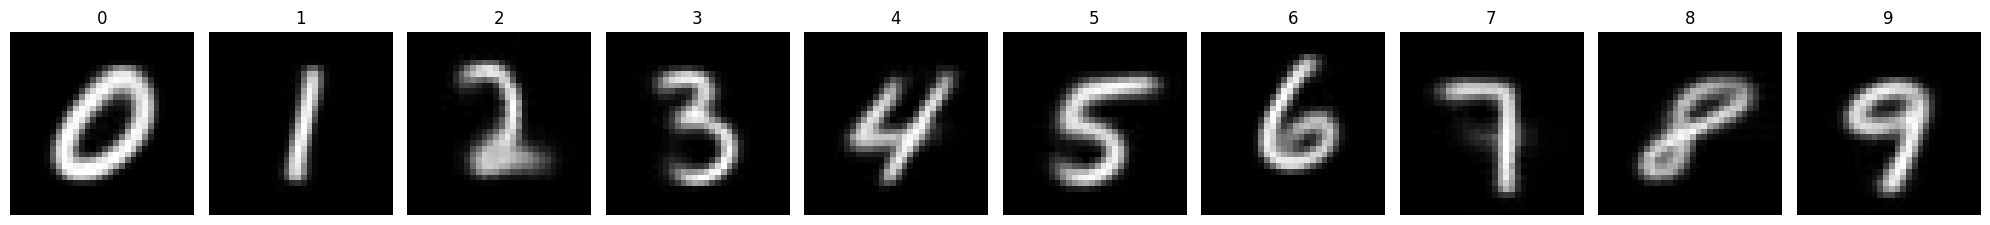

Epoch 27/50
468/468 [==============================] - 63s 134ms/step - loss: 0.1266 - noise_loss: 0.0912 - kl_loss: 3.5438 - val_loss: 0.1249 - val_noise_loss: 0.0900 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.4912 - learning_rate: 4.3733e-04


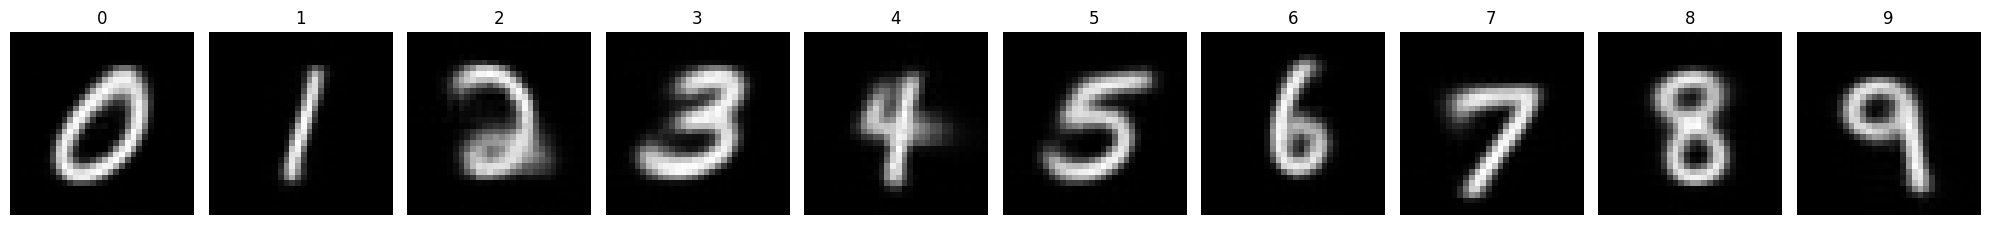

Epoch 28/50
468/468 [==============================] - 63s 134ms/step - loss: 0.1264 - noise_loss: 0.0909 - kl_loss: 3.5504 - val_loss: 0.1249 - val_noise_loss: 0.0898 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.5102 - learning_rate: 4.0631e-04


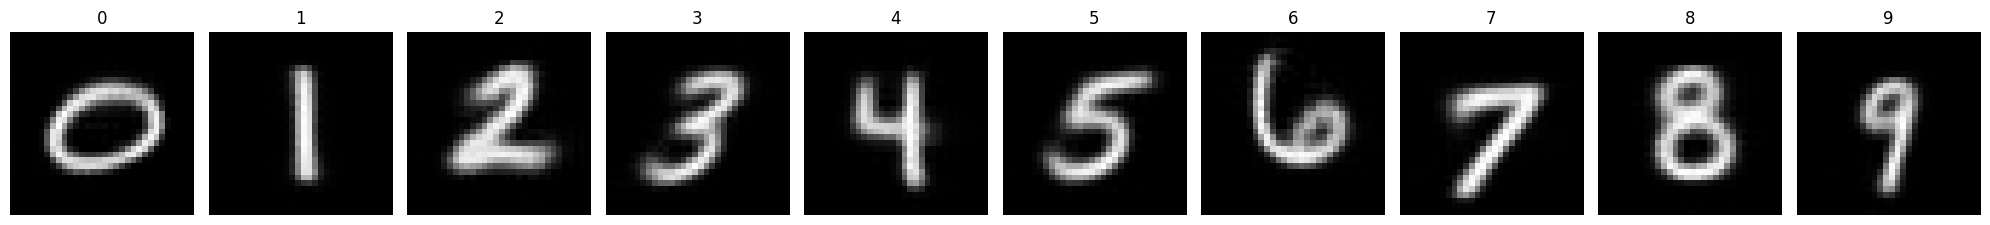

Epoch 29/50
468/468 [==============================] - 63s 134ms/step - loss: 0.1262 - noise_loss: 0.0905 - kl_loss: 3.5693 - val_loss: 0.1245 - val_noise_loss: 0.0892 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.5295 - learning_rate: 3.7566e-04


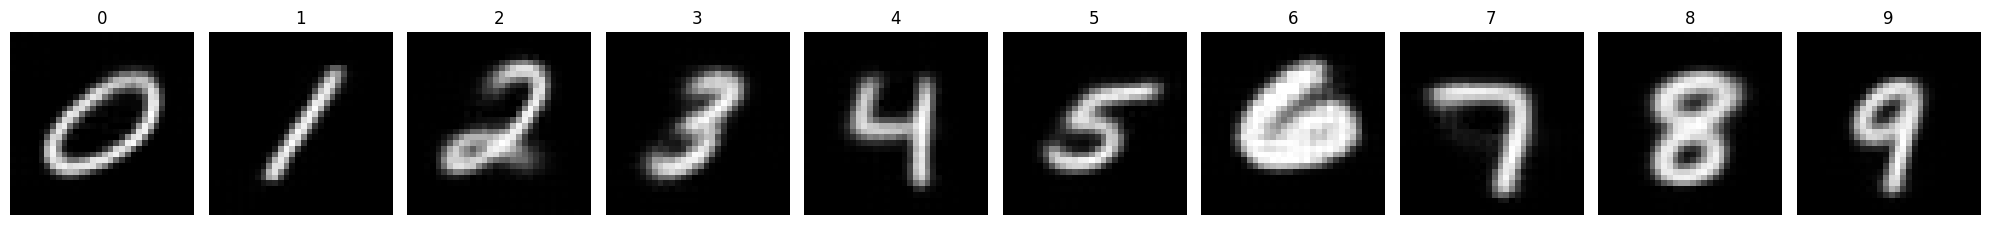

Epoch 30/50
468/468 [==============================] - 63s 134ms/step - loss: 0.1261 - noise_loss: 0.0902 - kl_loss: 3.5852 - val_loss: 0.1247 - val_noise_loss: 0.0893 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.5470 - learning_rate: 3.4549e-04


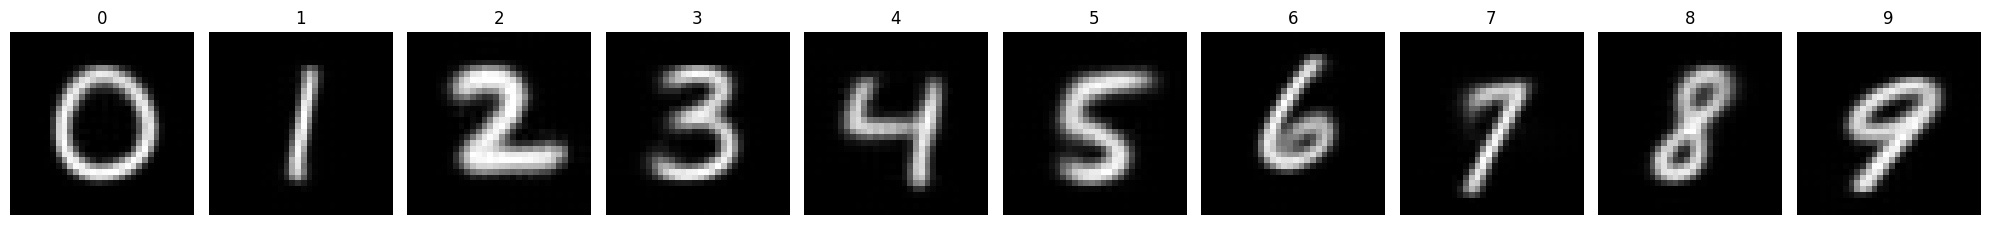

Epoch 31/50
468/468 [==============================] - 63s 134ms/step - loss: 0.1259 - noise_loss: 0.0898 - kl_loss: 3.6044 - val_loss: 0.1248 - val_noise_loss: 0.0891 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.5669 - learning_rate: 3.1594e-04


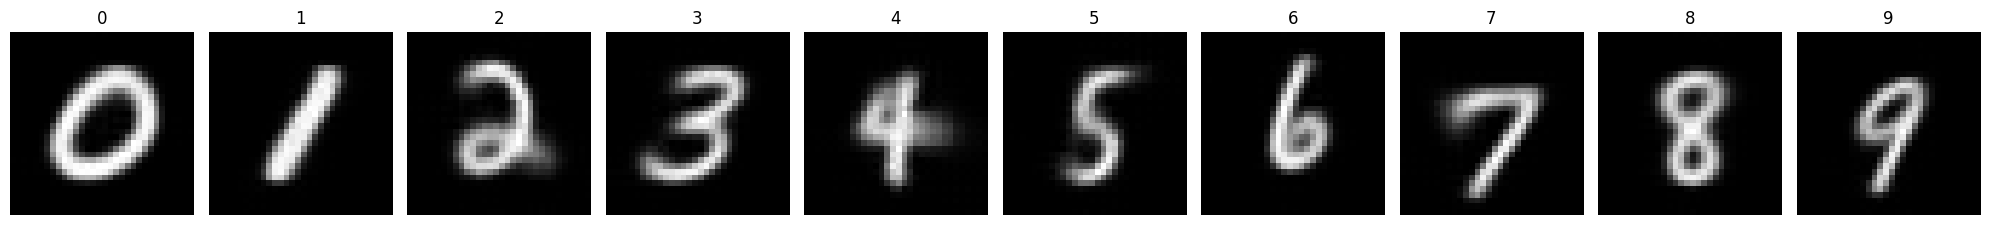

Epoch 32/50
468/468 [==============================] - 63s 134ms/step - loss: 0.1257 - noise_loss: 0.0896 - kl_loss: 3.6042 - val_loss: 0.1245 - val_noise_loss: 0.0887 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.5795 - learning_rate: 2.8711e-04


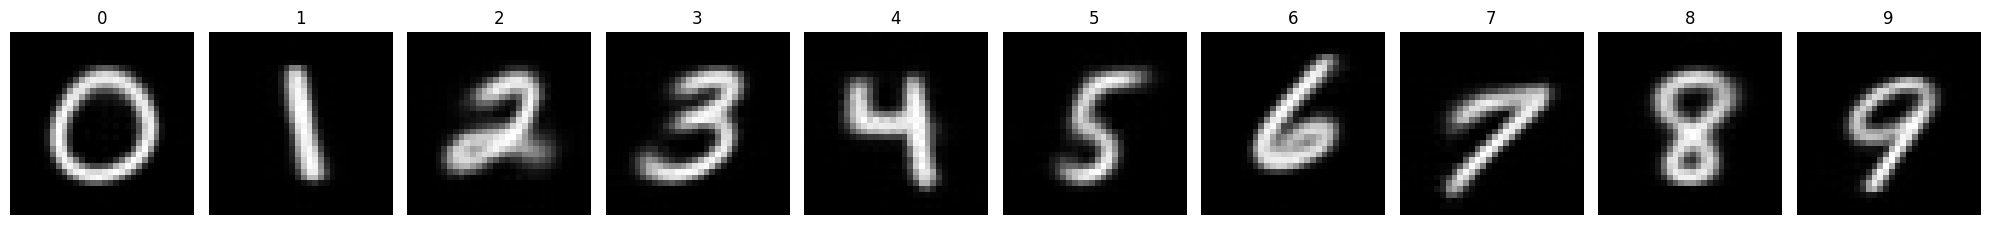

Epoch 33/50
468/468 [==============================] - 63s 135ms/step - loss: 0.1256 - noise_loss: 0.0894 - kl_loss: 3.6212 - val_loss: 0.1243 - val_noise_loss: 0.0883 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.5932 - learning_rate: 2.5912e-04


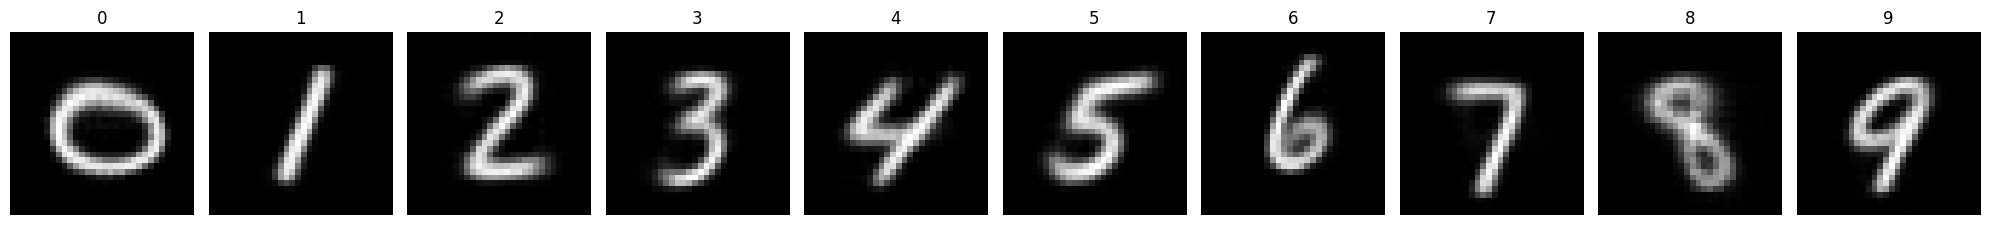

Epoch 34/50
468/468 [==============================] - 63s 134ms/step - loss: 0.1254 - noise_loss: 0.0892 - kl_loss: 3.6291 - val_loss: 0.1243 - val_noise_loss: 0.0883 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.6053 - learning_rate: 2.3209e-04


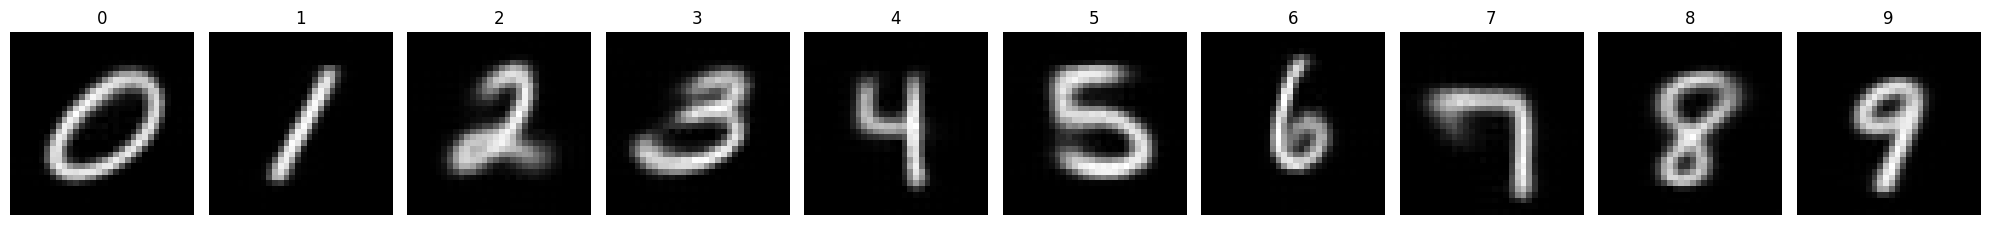

Epoch 35/50
468/468 [==============================] - 63s 134ms/step - loss: 0.1253 - noise_loss: 0.0889 - kl_loss: 3.6445 - val_loss: 0.1243 - val_noise_loss: 0.0881 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.6174 - learning_rate: 2.0611e-04


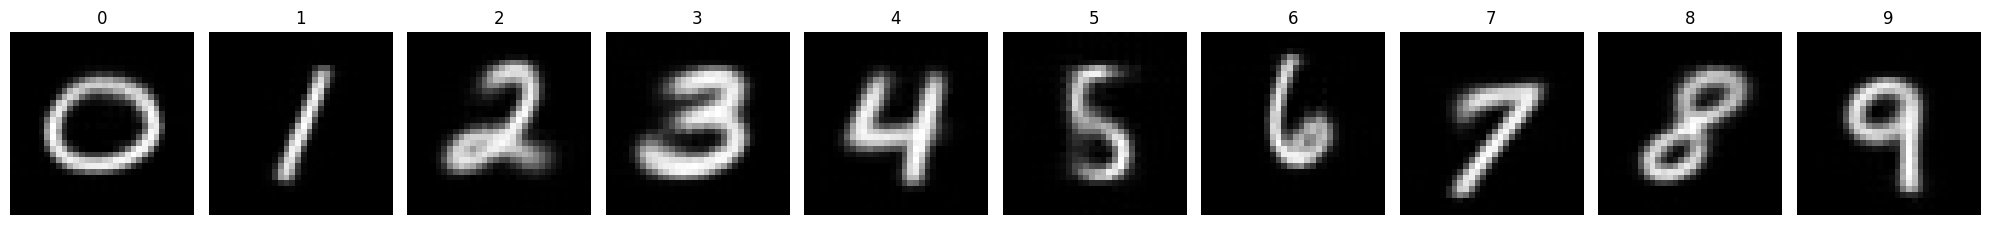

Epoch 36/50
468/468 [==============================] - 63s 135ms/step - loss: 0.1251 - noise_loss: 0.0886 - kl_loss: 3.6493 - val_loss: 0.1244 - val_noise_loss: 0.0881 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.6272 - learning_rate: 1.8129e-04


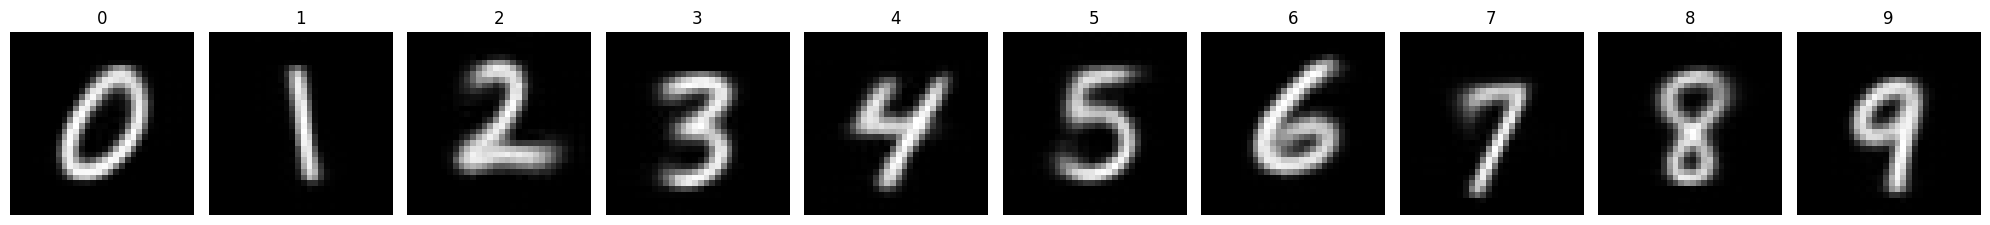

Epoch 37/50
468/468 [==============================] - 63s 134ms/step - loss: 0.1250 - noise_loss: 0.0883 - kl_loss: 3.6605 - val_loss: 0.1243 - val_noise_loss: 0.0879 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.6371 - learning_rate: 1.5773e-04


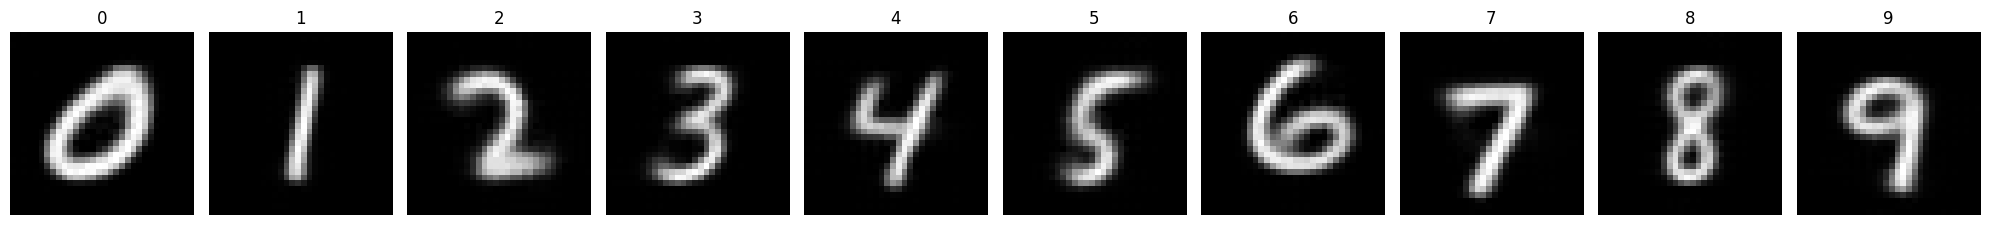

Epoch 38/50
468/468 [==============================] - 63s 135ms/step - loss: 0.1250 - noise_loss: 0.0882 - kl_loss: 3.6816 - val_loss: 0.1241 - val_noise_loss: 0.0875 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.6509 - learning_rate: 1.3552e-04


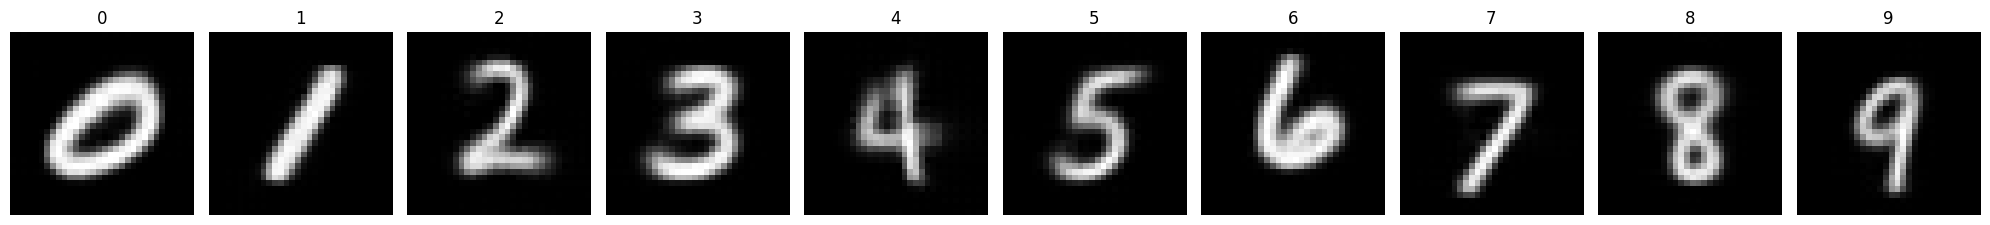

Epoch 39/50
468/468 [==============================] - 59s 126ms/step - loss: 0.1248 - noise_loss: 0.0880 - kl_loss: 3.6754 - val_loss: 0.1239 - val_noise_loss: 0.0873 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.6570 - learning_rate: 1.1474e-04


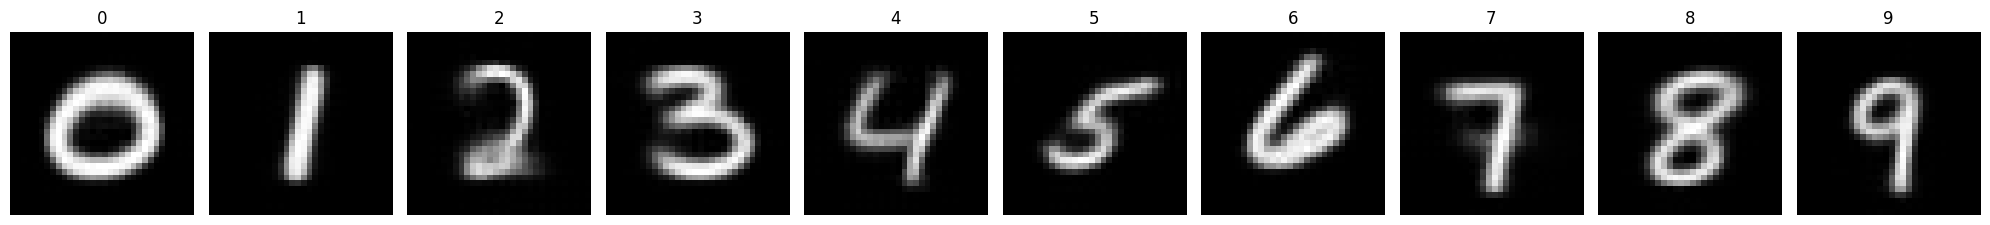

Epoch 40/50
468/468 [==============================] - 52s 112ms/step - loss: 0.1248 - noise_loss: 0.0879 - kl_loss: 3.6904 - val_loss: 0.1239 - val_noise_loss: 0.0872 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.6669 - learning_rate: 9.5491e-05


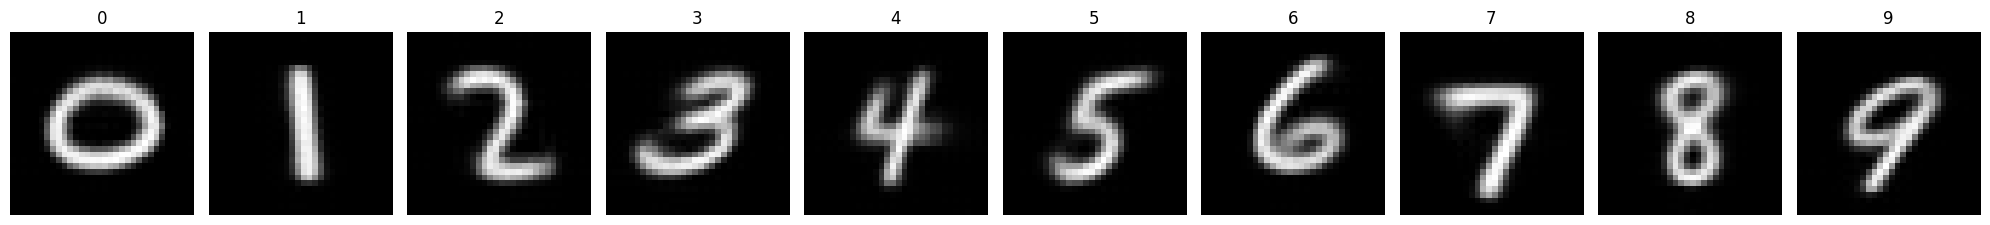

Epoch 41/50
468/468 [==============================] - 52s 111ms/step - loss: 0.1246 - noise_loss: 0.0877 - kl_loss: 3.6842 - val_loss: 0.1240 - val_noise_loss: 0.0873 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.6701 - learning_rate: 7.7836e-05


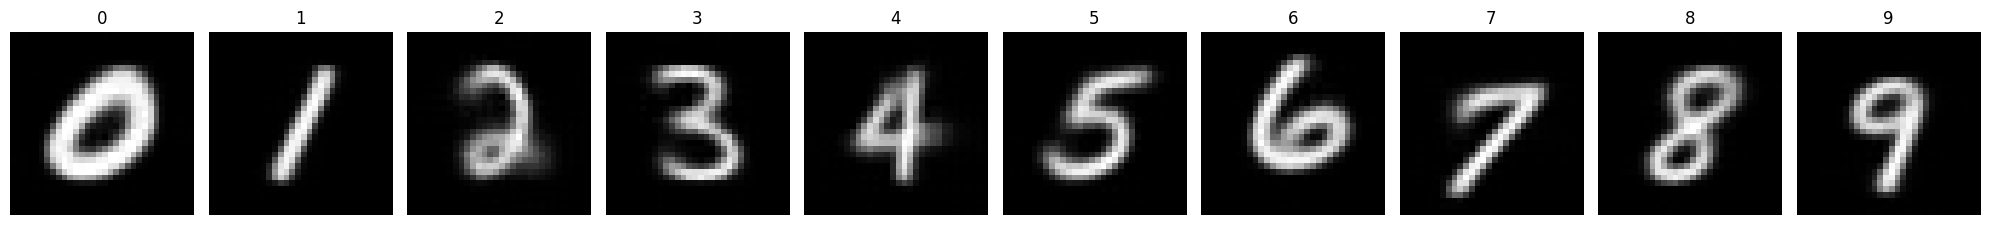

Epoch 42/50
468/468 [==============================] - 52s 111ms/step - loss: 0.1245 - noise_loss: 0.0875 - kl_loss: 3.6939 - val_loss: 0.1242 - val_noise_loss: 0.0874 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.6757 - learning_rate: 6.1847e-05


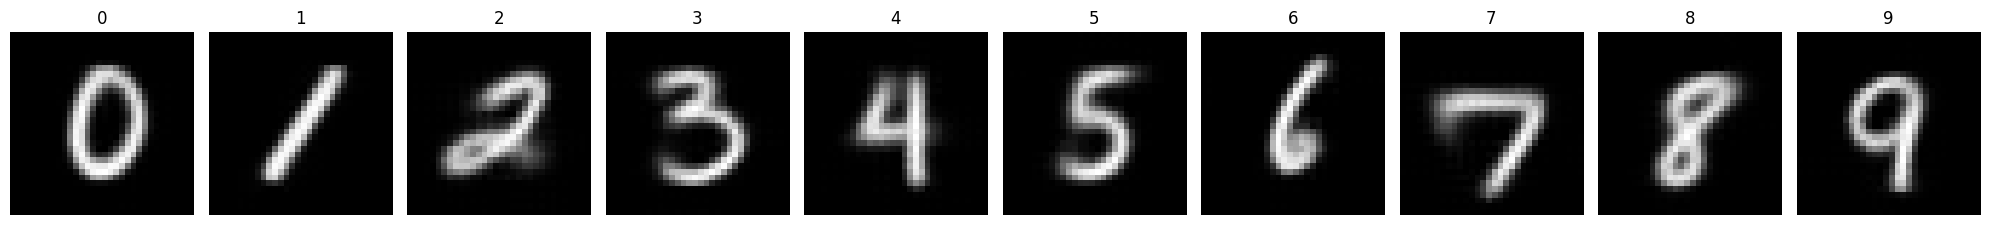

Epoch 43/50
468/468 [==============================] - 52s 111ms/step - loss: 0.1245 - noise_loss: 0.0875 - kl_loss: 3.7028 - val_loss: 0.1241 - val_noise_loss: 0.0873 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.6823 - learning_rate: 4.7586e-05


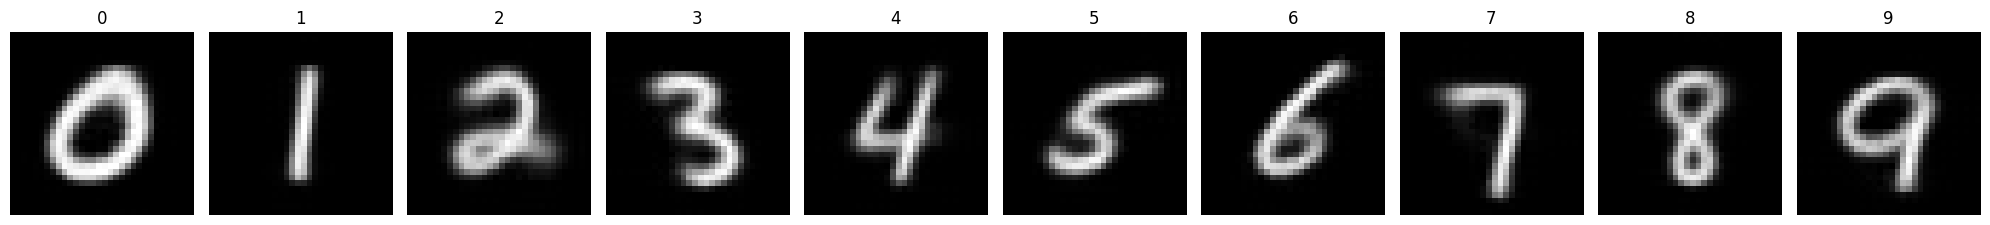

Epoch 44/50
468/468 [==============================] - 52s 111ms/step - loss: 0.1244 - noise_loss: 0.0874 - kl_loss: 3.6979 - val_loss: 0.1239 - val_noise_loss: 0.0870 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.6847 - learning_rate: 3.5112e-05


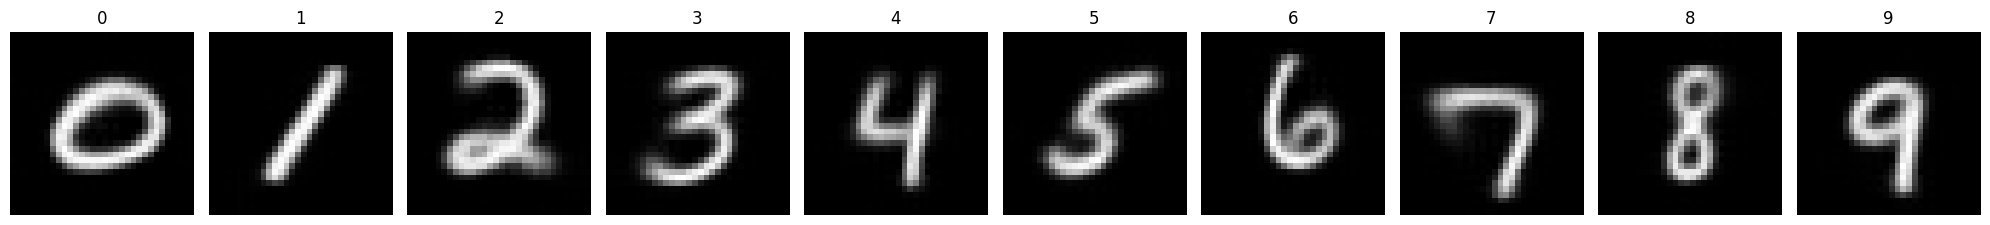

Epoch 45/50
468/468 [==============================] - 52s 111ms/step - loss: 0.1244 - noise_loss: 0.0873 - kl_loss: 3.7111 - val_loss: 0.1239 - val_noise_loss: 0.0870 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.6907 - learning_rate: 2.4472e-05


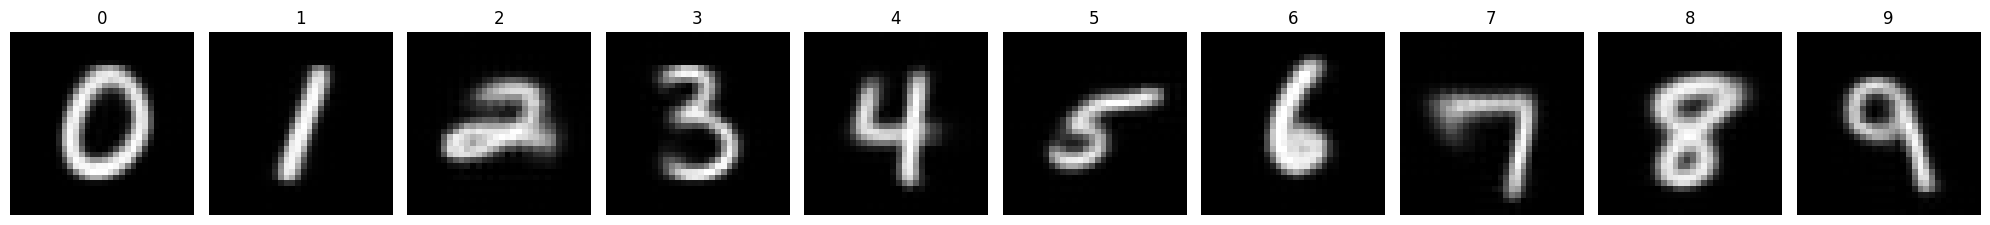

Epoch 46/50
468/468 [==============================] - 52s 111ms/step - loss: 0.1244 - noise_loss: 0.0872 - kl_loss: 3.7229 - val_loss: 0.1238 - val_noise_loss: 0.0868 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.6990 - learning_rate: 1.5708e-05


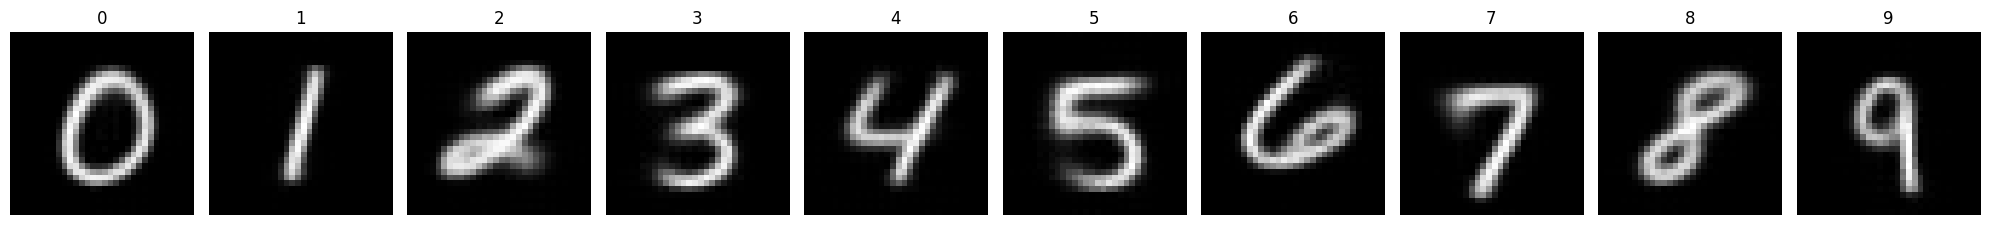

Epoch 47/50
468/468 [==============================] - 53s 114ms/step - loss: 0.1243 - noise_loss: 0.0871 - kl_loss: 3.7166 - val_loss: 0.1240 - val_noise_loss: 0.0870 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.7016 - learning_rate: 8.8564e-06


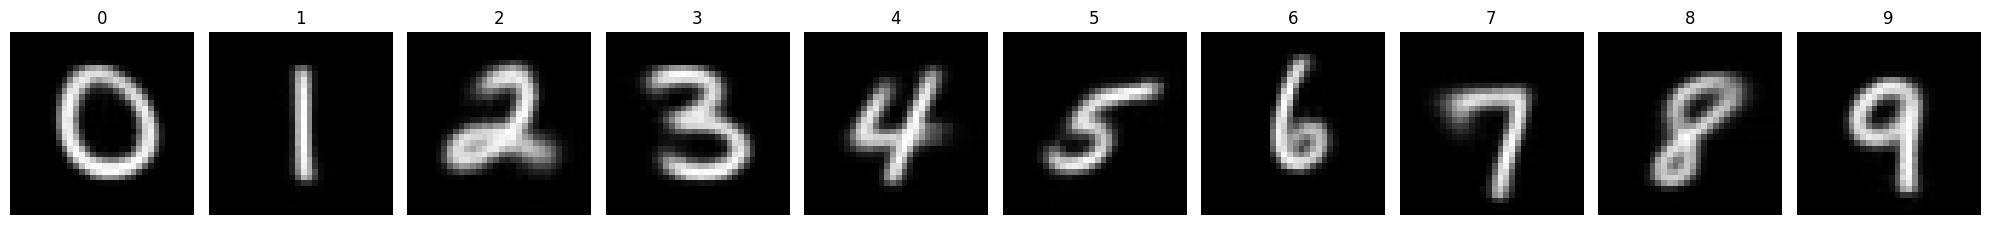

Epoch 48/50
468/468 [==============================] - 54s 115ms/step - loss: 0.1242 - noise_loss: 0.0871 - kl_loss: 3.7072 - val_loss: 0.1241 - val_noise_loss: 0.0871 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.6996 - learning_rate: 3.9426e-06


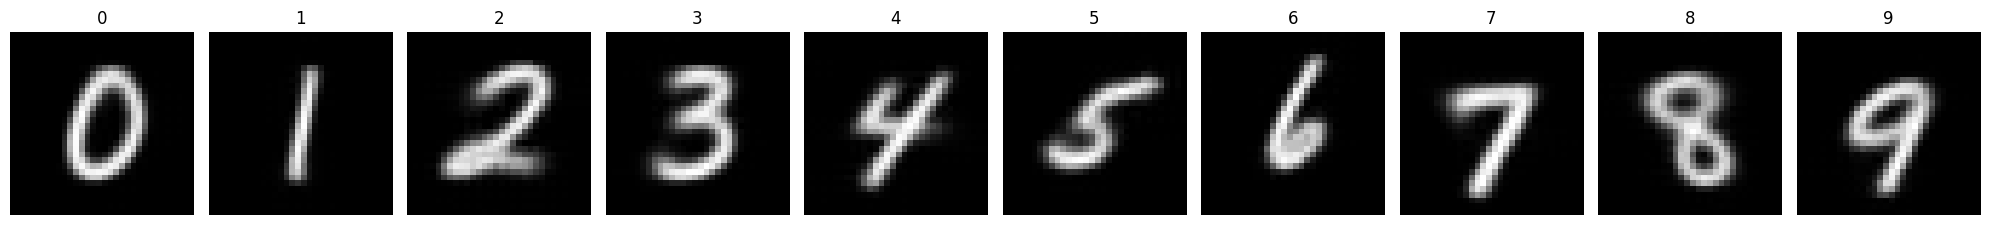

Epoch 49/50
468/468 [==============================] - 58s 124ms/step - loss: 0.1243 - noise_loss: 0.0871 - kl_loss: 3.7137 - val_loss: 0.1239 - val_noise_loss: 0.0869 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.7011 - learning_rate: 9.8664e-07


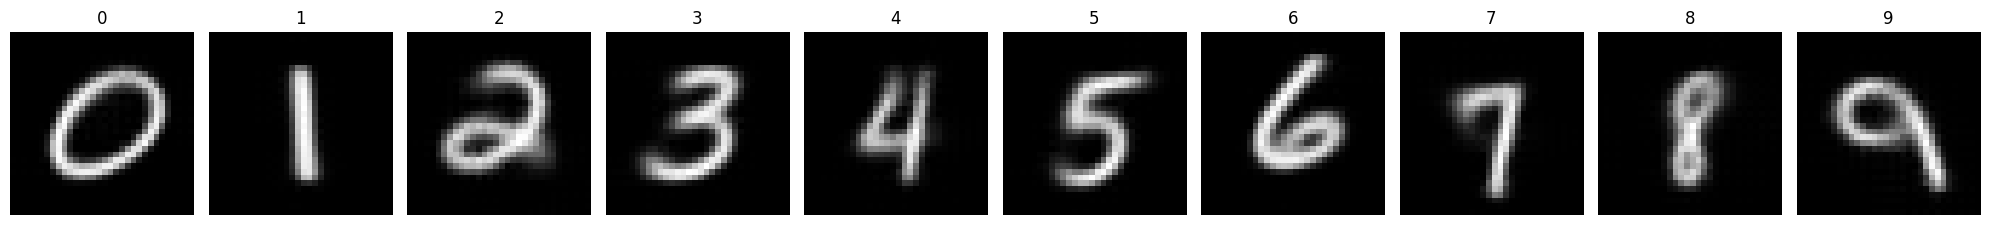

Epoch 50/50
468/468 [==============================] - 53s 114ms/step - loss: 0.1243 - noise_loss: 0.0871 - kl_loss: 3.7189 - val_loss: 0.1236 - val_noise_loss: 0.0866 - val_image_loss: 0.0000e+00 - val_kl_loss: 3.7038 - learning_rate: 0.0000e+00


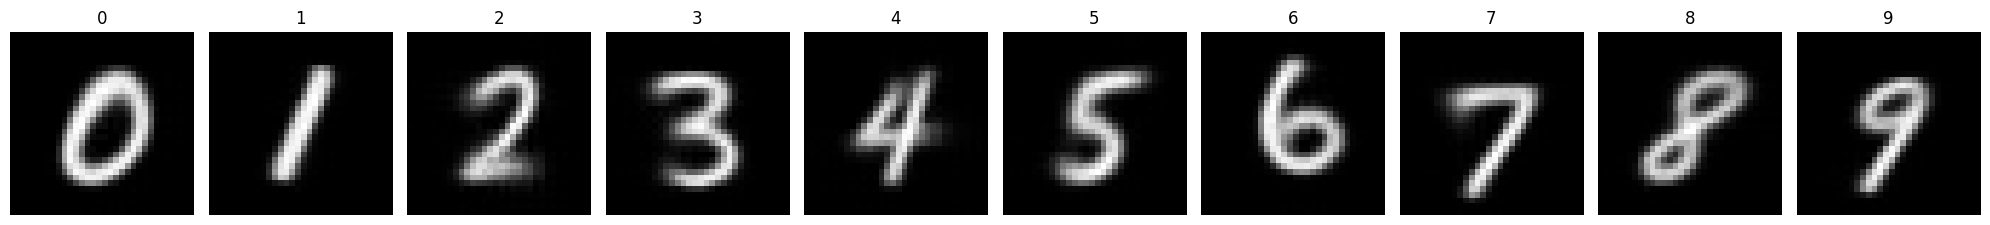

In [29]:
history = model.fit(
    trainset, 
    epochs=epochs, 
    validation_data=valset, 
    callbacks=callbacks_list, 
).history

In [30]:
# history = model.fit_progressively(
#     x=trainset.take(1), 
#     num_stages=10, 
#     stage_epochs=epochs, 
#     pacing_type="plateau", 
#     monitor="val_noise_loss", 
#     min_delta=1e-3, 
#     patience=1, 
#     validation_data=valset, 
#     callbacks=callbacks_list, 
# ).history

In [31]:
model.evaluate(valset)

79/79 [==============================] - 9s 85ms/step - loss: 0.1238 - noise_loss: 0.0867 - image_loss: 0.0000e+00 - kl_loss: 3.7038


[0.12375801801681519, 0.08671976625919342, 0.0, 3.7038285732269287]

In [32]:
model.evaluate(valset, network_name="raw")

79/79 [==============================] - 9s 87ms/step - loss: 0.1238 - noise_loss: 0.0867 - image_loss: 0.0000e+00 - kl_loss: 3.7085


[0.12380354106426239, 0.08671827614307404, 0.0, 3.708526134490967]

In [16]:
from common.utils import plot_images


# imgs = model.sample(labels=list(range(11)), scale=3., steps=1_000, eta=1., verbose=True)
# plot_images(imgs)

In [25]:
model.set_current_resolution(32)

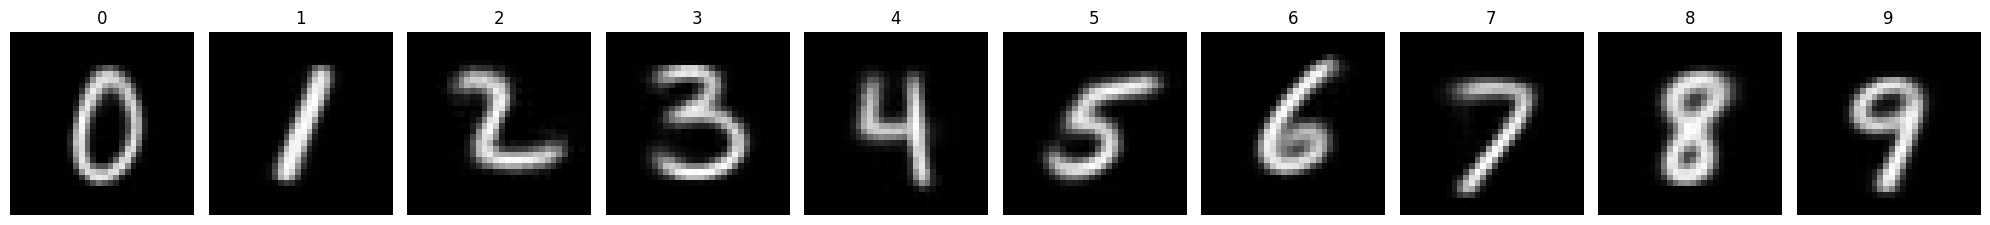

In [33]:
imgs = model.sample(labels=list(range(10)), verbose=True)
plot_images(imgs)

In [19]:
imgs = model.sample(labels=list(range(11)), verbose=True)
plot_images(imgs)

ValueError: labels must contain network IDs in [0, 10).

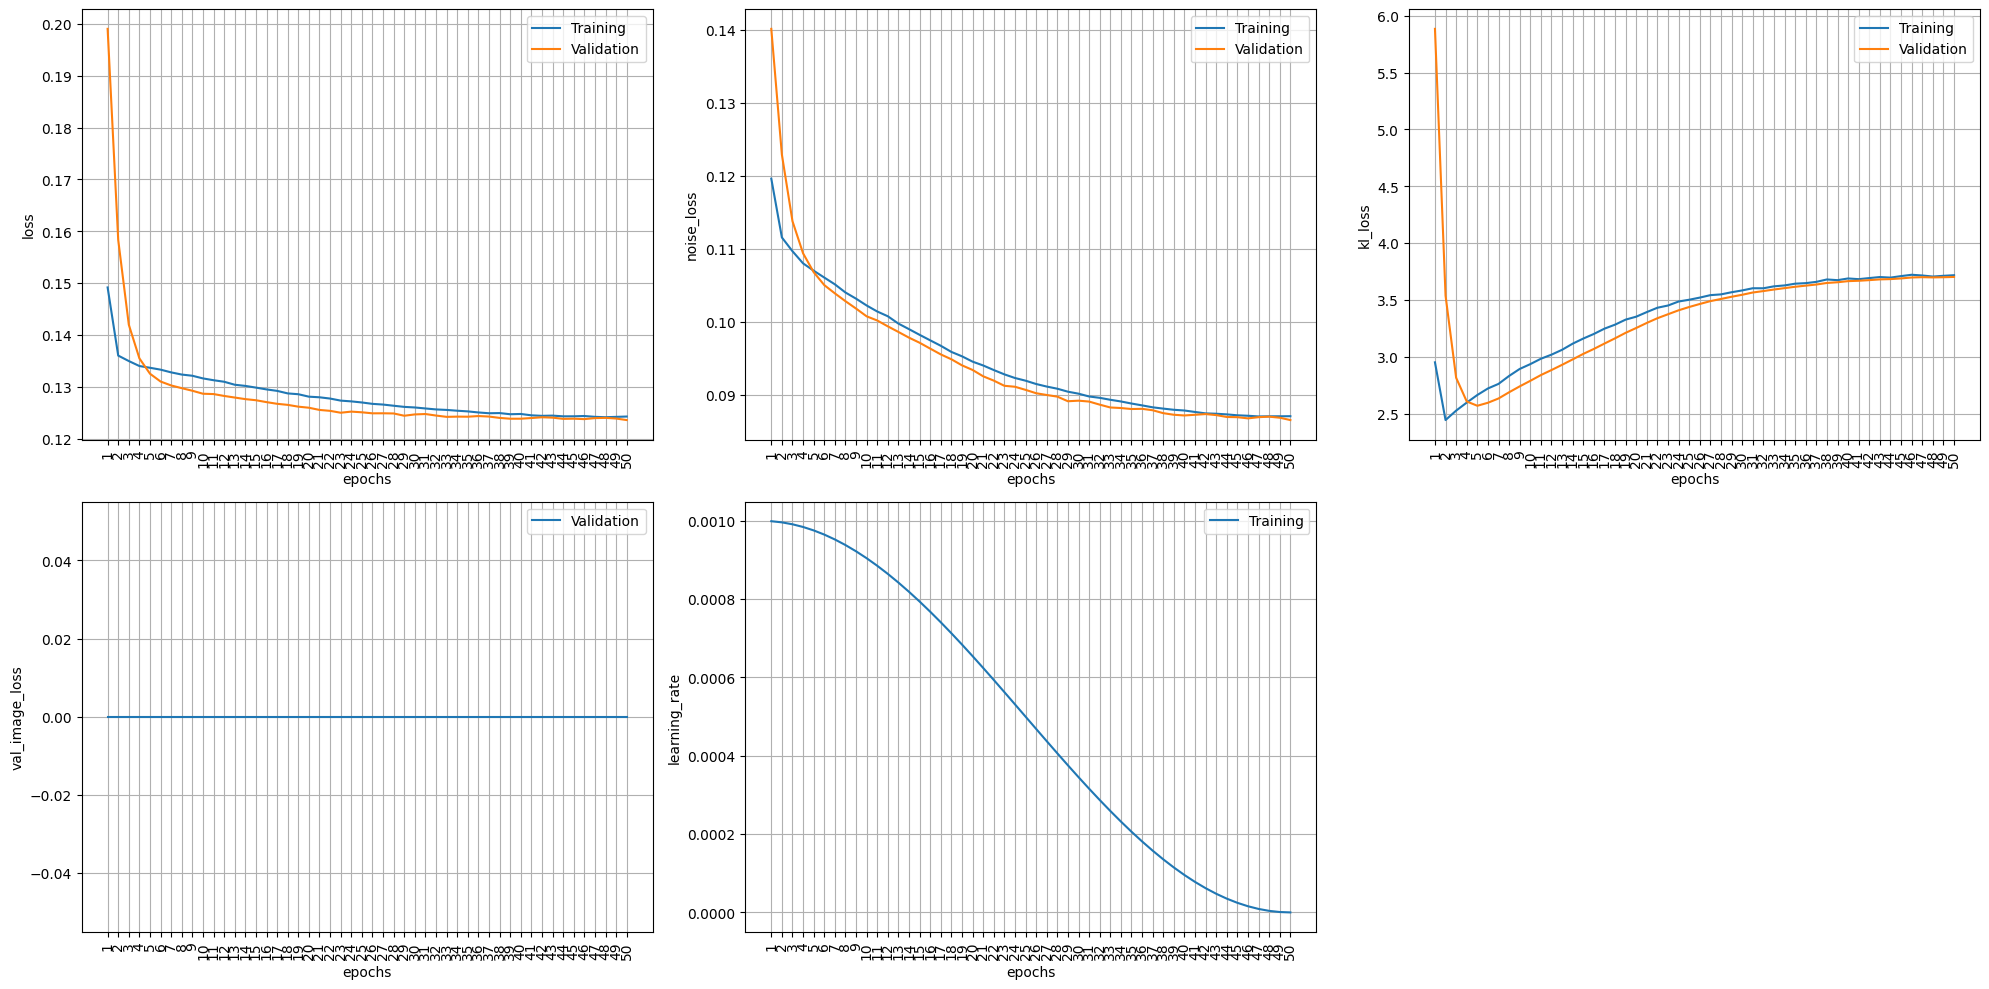

In [34]:
from common.utils import plot_history


plot_history(history)

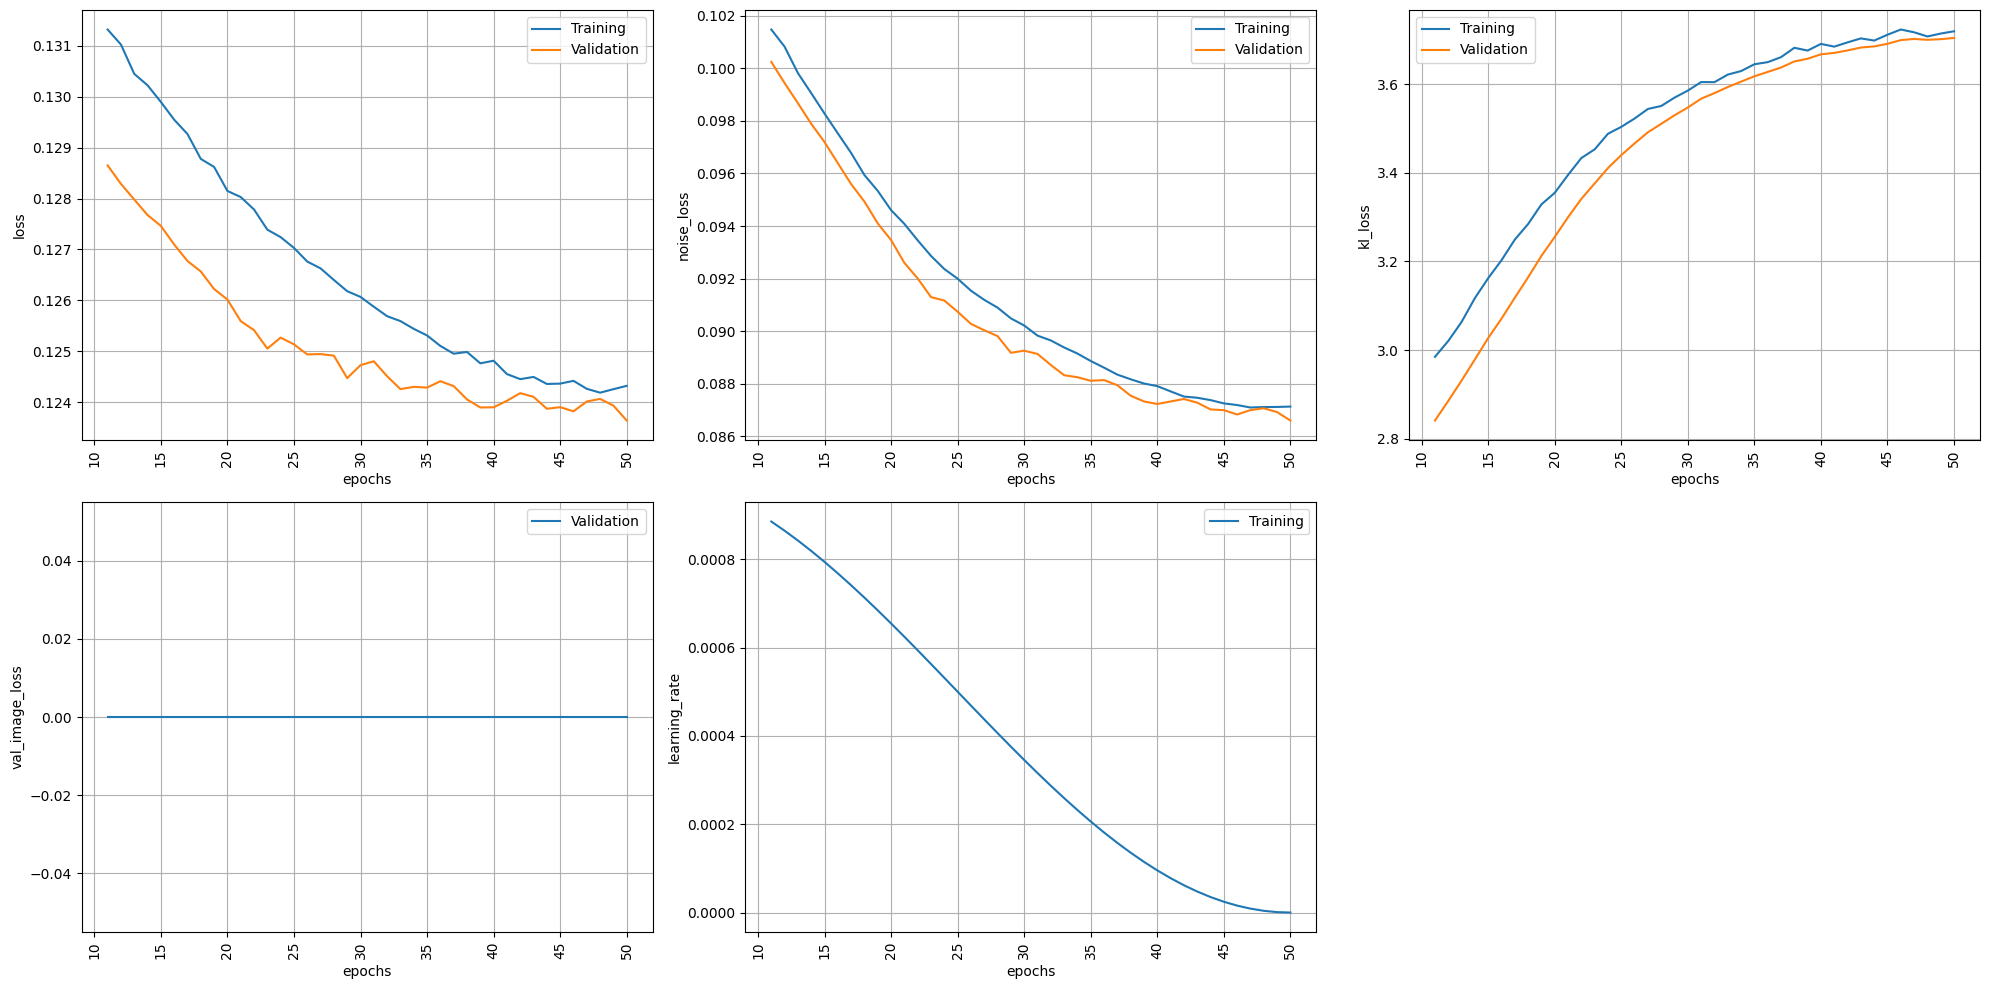

In [35]:
plot_history(history, show_all_x_ticks=False, range_=(10, None))